# Tests de modélisation

Ce notebook regroupe l'ensemble des modélisations réalisées pour prédire la valeur marchande des footballeurs professionnels.

**Contenu :**

Le notebook est organisé en **3 parties** pour garantir des comparaisons équitables :

```
PARTIE A ─── Pipeline commun
              └── Chargement, feature engineering, X/y, fonctions partagées

PARTIE B ─── Expérimentations
              ├── B0 : Modèles baseline
              ├── B1 : Comparaison des algorithmes (cible brute)
              ├── B2 : Comparaison des algorithmes (cible log)
              ├── B3 : Stacking OOF
              ├── B4 : Standardisation de la cible
              ├── B5 : Retrait des valeurs extrêmes
              ├── B6 : Réduction de dimensionnalité
              └── B7 : Modèles séparés Gardiens / Joueurs de champ

PARTIE C ─── Comparaison finale et sélection du modèle champion
              ├── Tableau unique, même test, même pipeline décision
              └── Choix du modèle final
```

## Partie A : Pipeline commun

### A.1 : Imports et configuration

In [99]:
import warnings
warnings.filterwarnings("ignore")
import time

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys
import os
import json

# Scikit-Learn
# Imputation et prétraitement
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer,
    StandardScaler,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.svm import SVR

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import cross_val_predict
from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import clone

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions/modelisations"))

%load_ext autoreload
%autoreload 2

# On importe les fonctions utiles à la modélisation
from tests_modelisation import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [100]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

### A.3 : Préparation des jeux de données X / y

In [101]:
colonne_cible  = "market_value_in_eur"

data = preparer_donnees(df_train, df_val, df_test, colonne_cible= colonne_cible)

# Extraction de toutes les variables du dictionnaire
X_train = data["X_train"]
y_train = data["y_train"]
y_train_log = data["y_train_log"]
sample_weights_train = data["sample_weights_train"]

X_val = data["X_val"]
y_val = data["y_val"]
y_val_log = data["y_val_log"]

X_test = data["X_test"]
y_test = data["y_test"]
y_test_log = data["y_test_log"]

X_train_sans_nan = data["X_train_sans_nan"]
X_val_sans_nan = data["X_val_sans_nan"]
X_test_sans_nan = data["X_test_sans_nan"]

X_train : (7404, 146) | X_val : (2431, 146) | X_test : (2295, 146)
Filtrage pour les modèles linéaires/SVR :
137 colonnes conservées sur 146.


### A.4 Paramètres d'optimisation d'hyperparamètres

In [102]:
# Nombre d'essais pour l'optimisation d'hyperparamètres et graine aléatoire

N_TRIALS     = 1
RANDOM_STATE = 1308

# On crée des copies des données pour les tests finaux réalisés en partie C

X_test_final, y_test_final, df_test_final = X_test.copy(), y_test.copy(), df_test.copy()
X_test_sans_nan_final =  X_test_sans_nan.copy()

## Partie B : Expérimentations

> Toutes les parties utilisent **exactement** les mêmes `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` issus de la partie A.

### B0 : Modèles baseline

On définit 5 modèles sans tuning : Random Forest, Extra Trees, XGBoost, LightGBM et CatBoost, avec des hyperparamètres fixes. L'objectif est d'établir une référence rapide avant toute optimisation.

#### B0.1 : Définition des modèles

In [38]:
modeles = {
    # Forêts
    "Random Forest": RandomForestRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100
    ),
    # Boosting
    "XGBoost": XGBRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100, learning_rate=0.1
    ),
    "LightGBM": LGBMRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100, learning_rate=0.1, verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308, iterations=100, learning_rate=0.1, verbose=0
    ),
}

#### B0.2 : Évaluation sur la validation

Évaluation de chaque modèle sur le jeu de validation. Les métriques calculées sont : MAE, RMSE, MAPE, R² et R² ajusté.

In [39]:
# Évaluation sur la validation

df_res_val, res_val_dict = evaluer_modeles(modeles, data, mode="val")

Entraînement de Random Forest...
   -> Validation | MAE : 3,542,450 € | RMSE : 6,766,621 € | MAPE : 70.38% | R² : 85.86% | R² Ajusté : 84.96%
Entraînement de Extra Trees...
   -> Validation | MAE : 3,332,044 € | RMSE : 6,303,096 € | MAPE : 69.06% | R² : 87.73% | R² Ajusté : 86.95%
Entraînement de XGBoost...
   -> Validation | MAE : 3,273,348 € | RMSE : 5,896,817 € | MAPE : 71.34% | R² : 89.26% | R² Ajusté : 88.58%
Entraînement de LightGBM...
   -> Validation | MAE : 3,252,614 € | RMSE : 6,065,886 € | MAPE : 71.65% | R² : 88.64% | R² Ajusté : 87.91%
Entraînement de CatBoost...
   -> Validation | MAE : 3,393,157 € | RMSE : 6,261,310 € | MAPE : 82.01% | R² : 87.90% | R² Ajusté : 87.12%

CLASSEMENT FINAL Validation (trié par MAE croissante)
       Modèle Erreur moyenne Validation (MAE) Score R² Validation Score R² Ajusté Validation
     LightGBM                     3,252,614 €              88.64%                     87.91%
      XGBoost                     3,273,348 €              89.26%  

#### B0.3 : Évaluation sur le test

Le test est évalué **une seule fois**, uniquement pour avoir une référence de la performance réelle avant tuning.

In [40]:
# Évaluation sur le test

df_res_test, res_test_dict = evaluer_modeles(modeles, data, mode="test")

Entraînement de Random Forest...
   -> Test | MAE : 3,765,331 € | RMSE : 7,247,051 € | MAPE : 66.03% | R² : 84.95% | R² Ajusté : 83.93%
Entraînement de Extra Trees...
   -> Test | MAE : 3,482,186 € | RMSE : 6,654,815 € | MAPE : 60.74% | R² : 87.31% | R² Ajusté : 86.45%
Entraînement de XGBoost...
   -> Test | MAE : 3,424,375 € | RMSE : 6,164,642 € | MAPE : 62.96% | R² : 89.11% | R² Ajusté : 88.37%
Entraînement de LightGBM...
   -> Test | MAE : 3,571,105 € | RMSE : 7,047,720 € | MAPE : 67.06% | R² : 85.77% | R² Ajusté : 84.80%
Entraînement de CatBoost...
   -> Test | MAE : 3,579,644 € | RMSE : 6,827,094 € | MAPE : 69.65% | R² : 86.64% | R² Ajusté : 85.74%

CLASSEMENT FINAL Test (trié par MAE croissante)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               3,424,375 €        89.11%               88.37%
  Extra Trees               3,482,186 €        87.31%               86.45%
     LightGBM               3,571,105 €        85.77%           

### B1 : Comparaison des algorithmes (cible brute)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.

#### B1.1 : Tuning Random Forest et Extra Trees

In [117]:
study_rf = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE) )

study_rf.optimize(
    lambda t: tune_forest(RandomForestRegressor, t, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

Best trial: 0. Best value: 8.61114e+06: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]

Meilleur RMSE : 8611139.784474818
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [118]:
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_et.optimize(
    lambda t: tune_forest(ExtraTreesRegressor, t, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)

Best trial: 0. Best value: 9.34494e+06: 100%|██████████| 1/1 [00:01<00:00,  1.44s/it]

Meilleur RMSE : 9344939.974022873
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


#### B1.2 : Tuning XGBoost

In [119]:
study_xgb = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_xgb.optimize(
    lambda t: tune_xgb(XGBRegressor, t, random_state=RANDOM_STATE,
                        X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val,
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)

Best trial: 0. Best value: 5.8696e+06: 100%|██████████| 1/1 [00:13<00:00, 13.61s/it]

Meilleur RMSE : 5869604.456703034
Meilleurs paramètres : {'n_estimators': 1250, 'max_depth': 10, 'learning_rate': 0.006318598359104425, 'subsample': 0.5446062880266449, 'colsample_bytree': 0.9627983128285522, 'min_child_weight': 5.228175246239128, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


#### B1.3 : Tuning LightGBM

In [ ]:
study_lgbm = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_lgbm.optimize(
    lambda t: tune_lgbm(LGBMRegressor, t, use_log=False, random_state=RANDOM_STATE,
                       X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)

Best trial: 0. Best value: 6.33686e+06: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]

Meilleur RMSE : 6336859.440387915
Meilleurs paramètres : {'n_estimators': 1250, 'num_leaves': 206, 'max_depth': 3, 'learning_rate': 0.006948545459606252, 'subsample': 0.9627983128285522, 'colsample_bytree': 0.7488513287494278, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


#### B1.4 : Tuning CatBoost

In [121]:
study_cat = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat.optimize(
    lambda t: tune_catboost(CatBoostRegressor, t, random_state=RANDOM_STATE,
                            X_train=X_train, y_train=y_train,
                            y_train_log=y_train_log, X_val=X_val, y_val=y_val, y_val_log=y_val_log),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)

Best trial: 0. Best value: 5.78312e+06: 100%|██████████| 1/1 [00:10<00:00, 10.15s/it]

Meilleur RMSE : 5783116.289172065
Meilleurs paramètres : {'learning_rate': 0.015185816814751393, 'iterations': 2500, 'depth': 4, 'l2_leaf_reg': 1.8029131844796091, 'subsample': 0.9627983128285522}


#### B1.5 : Tuning SVR & ElasticNet

SVR et ElasticNet nécessitent une standardisation préalable et ne tolèrent pas les NaN.
On travaille sur un sous-ensemble de colonnes sans valeurs manquantes.

In [122]:
study_svr = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_svr.optimize(
    lambda t: tune_svr(t, use_log=False, X_train_sans_nan=X_train_sans_nan,
                       y_train=y_train, y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val, ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Meilleur RMSE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)

Best trial: 0. Best value: 1.93118e+07: 100%|██████████| 1/1 [00:06<00:00,  6.72s/it]

Meilleur RMSE : 19311750.966076232
Meilleurs paramètres : {'C': 0.05318052579272604, 'epsilon': 0.24488221650133354, 'kernel': 'linear', 'gamma': 'scale'}


In [123]:
study_enet = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_enet.optimize(
    lambda t: tune_enet( t, use_log=False, random_state=RANDOM_STATE,X_train_sans_nan=X_train_sans_nan,
                        y_train=y_train, y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val,
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)

Best trial: 0. Best value: 1.03058e+07: 100%|██████████| 1/1 [00:08<00:00,  8.23s/it]

Meilleur RMSE : 10305775.363933714
Meilleurs paramètres : {'alpha': 0.0008075897228004992, 'l1_ratio': 0.7963190825116033}


#### B1.6 : Construction des modèles finaux

In [124]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":   ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost":       XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                                   objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM":      LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost":      CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                        random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_sans_nan = {
    "SVR":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

#### B1.7 : Évaluation sur la validation

On évalue chaque modèle tuné sur la validation pour comparer et choisir le meilleur avant de toucher au test.

In [125]:
evaluer_modeles_tuned(
    modeles_tuned,
    modeles_tuned_sans_nan,
    data=data,
    mode="val",
    use_log=False,
)

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost        3.107535e+06  5.869604e+06  0.667011  0.893630   0.886830
CatBoost       3.229925e+06  5.783130e+06  0.770957  0.896741   0.890140
LightGBM       3.528861e+06  6.336859e+06  0.880593  0.876020   0.868095
Random Forest  4.437798e+06  8.611140e+06  0.961375  0.771059   0.756424
Extra Trees    4.895426e+06  9.344940e+06  1.056630  0.730378   0.713143
ElasticNet     6.324311e+06  1.030578e+07  2.838709  0.672083   0.652491
SVR            9.737952e+06  1.931175e+07  1.971546 -0.151452  -0.220248


,MAE,RMSE,MAPE,R2,R2 Ajusté
XGBoost,3.107535e+06,5.869604e+06,0.667011,0.893630,0.886830
CatBoost,3.229925e+06,5.783130e+06,0.770957,0.896741,0.890140
LightGBM,3.528861e+06,6.336859e+06,0.880593,0.876020,0.868095
Random Forest,4.437798e+06,8.611140e+06,0.961375,0.771059,0.756424
Extra Trees,4.895426e+06,9.344940e+06,1.056630,0.730378,0.713143
ElasticNet,6.324311e+06,1.030578e+07,2.838709,0.672083,0.652491
SVR,9.737952e+06,1.931175e+07,1.971546,-0.151452,-0.220248


#### B1.8 : Évaluation finale sur le test

In [126]:
evaluer_modeles_tuned(
    modeles_tuned,
    modeles_tuned_sans_nan,
    data=data,
    mode="test",
    use_log=False,
)

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost        3.336616e+06  6.440051e+06  0.599092  0.881162   0.873084
CatBoost       3.429225e+06  6.192864e+06  0.672393  0.890109   0.882640
LightGBM       3.777964e+06  7.109433e+06  0.799353  0.855174   0.845330
Random Forest  4.724369e+06  9.411116e+06  0.906620  0.746218   0.728969
Extra Trees    5.251091e+06  1.020282e+07  1.017171  0.701724   0.681450
ElasticNet     6.791740e+06  1.121930e+07  2.499677  0.639331   0.616423
SVR            1.042314e+07  2.032332e+07  1.897953 -0.183498  -0.258667


,MAE,RMSE,MAPE,R2,R2 Ajusté
XGBoost,3.336616e+06,6.440051e+06,0.599092,0.881162,0.873084
CatBoost,3.429225e+06,6.192864e+06,0.672393,0.890109,0.882640
LightGBM,3.777964e+06,7.109433e+06,0.799353,0.855174,0.845330
Random Forest,4.724369e+06,9.411116e+06,0.906620,0.746218,0.728969
Extra Trees,5.251091e+06,1.020282e+07,1.017171,0.701724,0.681450
ElasticNet,6.791740e+06,1.121930e+07,2.499677,0.639331,0.616423
SVR,1.042314e+07,2.032332e+07,1.897953,-0.183498,-0.258667


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.

#### B2.1 : Tuning Random Forest & Extra Trees

In [69]:
study_rf_log = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE) )

study_rf_log.optimize(
    lambda t: tune_forest(RandomForestRegressor, t, use_log=True, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

Best trial: 0. Best value: 1.04428e+07: 100%|██████████| 1/1 [00:01<00:00,  1.61s/it]

Meilleur RMSE : 10442845.012949724
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [13]:
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_et_log.optimize(
    lambda t: tune_forest(ExtraTreesRegressor, t, use_log=True, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)

Best trial: 0. Best value: 1.13297e+07: 100%|██████████| 1/1 [00:01<00:00,  1.80s/it]

Meilleur RMSE : 11329691.512996294
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


#### B2.3 : Tuning XGBoost

In [74]:
study_xgb_log = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_xgb_log.optimize(
    lambda t: tune_xgb(XGBRegressor, t, transfo={"transform": np.log1p, "inverse_transform": np.expm1}, random_state=RANDOM_STATE,
                        X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)

  0%|          | 0/1 [00:00<?, ?it/s]

Best trial: 0. Best value: 6.02176e+06: 100%|██████████| 1/1 [00:24<00:00, 24.45s/it]

Meilleur RMSE : 6021762.175517915
Meilleurs paramètres : {'n_estimators': 1250, 'max_depth': 10, 'learning_rate': 0.006318598359104425, 'subsample': 0.5446062880266449, 'colsample_bytree': 0.9627983128285522, 'min_child_weight': 5.228175246239128, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


#### B2.4 : Tuning LightGBM

In [71]:
study_lgbm_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_lgbm_log.optimize(
    lambda t: tune_lgbm(LGBMRegressor, t, transfo={"transform": np.log1p, "inverse_transform": np.expm1}, random_state=RANDOM_STATE,
                       X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)

Best trial: 0. Best value: 7.38676e+06: 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]

Meilleur RMSE : 7386763.03848607
Meilleurs paramètres : {'n_estimators': 1250, 'num_leaves': 206, 'max_depth': 3, 'learning_rate': 0.006948545459606252, 'subsample': 0.9627983128285522, 'colsample_bytree': 0.7488513287494278, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


#### B2.5 : Tuning CatBoost

In [73]:
study_cat_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat_log.optimize(
    lambda t: tune_catboost(CatBoostRegressor, t, transfo={"transform": np.log1p, "inverse_transform": np.expm1}, random_state=RANDOM_STATE,
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)

Best trial: 0. Best value: 6.39101e+06: 100%|██████████| 1/1 [00:33<00:00, 33.44s/it]

Meilleur RMSE : 6391010.217326488
Meilleurs paramètres : {'learning_rate': 0.009764383228920896, 'iterations': 8500, 'depth': 4, 'l2_leaf_reg': 1.8029131844796091, 'subsample': 0.9627983128285522}


#### B2.6 : Tuning SVR & ElasticNet

SVR et ElasticNet nécessitent une standardisation préalable et ne tolèrent pas les NaN.
On travaille sur un sous-ensemble de colonnes sans valeurs manquantes.

In [17]:
study_svr_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_svr_log.optimize(
    lambda t: tune_svr(t, use_log=True, X_train_sans_nan=X_train_sans_nan, y_train=y_train,
                       y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val, ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Meilleur RMSE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)

Best trial: 0. Best value: 1.29991e+07: 100%|██████████| 1/1 [00:08<00:00,  8.45s/it]

Meilleur RMSE : 12999068.160571307
Meilleurs paramètres : {'C': 0.05318052579272604, 'epsilon': 0.24488221650133354, 'kernel': 'linear', 'gamma': 'scale'}


In [18]:
study_enet_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_enet_log.optimize(
    lambda t: tune_enet(t, use_log=True, random_state=RANDOM_STATE, X_train_sans_nan=X_train_sans_nan,
                        y_train=y_train, y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)

Best trial: 0. Best value: 1.32101e+07: 100%|██████████| 1/1 [00:03<00:00,  3.76s/it]

Meilleur RMSE : 13210082.620142793
Meilleurs paramètres : {'alpha': 0.0008075897228004992, 'l1_ratio': 0.7963190825116033}


#### B2.7 — Construction des modèles finaux

In [19]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)":   ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)":       XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                          objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)":      LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)":      CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                               random_state=RANDOM_STATE, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

In [20]:
# Regroupement de tous les meilleurs paramètres dans un seul dictionnaire
meilleurs_params = {
    "Random Forest": study_rf_log.best_params,
    "Extra Trees": study_et_log.best_params,
    "XGBoost": study_xgb_log.best_params,
    "LightGBM": study_lgbm_log.best_params,
    "CatBoost": study_cat_log.best_params,
    "SVR": study_svr_log.best_params,
    "ElasticNet": study_enet_log.best_params,
}

# Sauvegarde dans un fichier JSON
with open("../modelisation/meilleurs_hyperparametres.json", "w") as f:
    json.dump(meilleurs_params, f, indent=4)

#### B2.8 : Évaluation et comparaison avec/sans transformation

La fonction `evaluer_log` entraîne sur `log1p(y)`, retransforme les prédictions avec `expm1`, puis calcule toutes les métriques en euros, ce qui rend les deux approches directement comparables.

In [21]:
evaluer_modeles_tuned(
    modeles_tuned_log,
    modeles_tuned_log_sans_nan,
    data=data,
    mode="val",
    use_log=True,
)

Entraînement (tuné) de Random Forest (log)...
Entraînement (tuné) de Extra Trees (log)...
Entraînement (tuné) de XGBoost (log)...
Entraînement (tuné) de LightGBM (log)...
Entraînement (tuné) de CatBoost (log)...
Entraînement (tuné) de SVR (log)...
Entraînement (tuné) de ElasticNet (log)...

CLASSEMENT (Validation, modèles tunés)
                              MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)        3.020153e+06  6.021762e+06  0.425905  0.888043   0.880887
CatBoost (log)       3.281176e+06  6.393533e+06  0.438511  0.873793   0.865725
LightGBM (log)       3.459357e+06  7.386763e+06  0.470581  0.831535   0.820766
SVR (log)            4.597556e+06  1.299907e+07  0.625595  0.478293   0.447122
Random Forest (log)  4.735035e+06  1.044285e+07  0.529752  0.663302   0.641780
ElasticNet (log)     4.774647e+06  1.321008e+07  0.592932  0.461217   0.429027
Extra Trees (log)    5.184058e+06  1.132969e+07  0.571968  0.603687   0.578353


,MAE,RMSE,MAPE,R2,R2 Ajusté
XGBoost (log),3.020153e+06,6.021762e+06,0.425905,0.888043,0.880887
CatBoost (log),3.281176e+06,6.393533e+06,0.438511,0.873793,0.865725
LightGBM (log),3.459357e+06,7.386763e+06,0.470581,0.831535,0.820766
SVR (log),4.597556e+06,1.299907e+07,0.625595,0.478293,0.447122
Random Forest (log),4.735035e+06,1.044285e+07,0.529752,0.663302,0.641780
ElasticNet (log),4.774647e+06,1.321008e+07,0.592932,0.461217,0.429027
Extra Trees (log),5.184058e+06,1.132969e+07,0.571968,0.603687,0.578353


#### B2.9 — Évaluation finale sur le test

In [22]:
evaluer_modeles_tuned(
    modeles_tuned_log,
    modeles_tuned_log_sans_nan,
    data=data,
    mode="test",
    use_log=True,
)

Entraînement (tuné) de Random Forest (log)...
Entraînement (tuné) de Extra Trees (log)...
Entraînement (tuné) de XGBoost (log)...
Entraînement (tuné) de LightGBM (log)...
Entraînement (tuné) de CatBoost (log)...
Entraînement (tuné) de SVR (log)...
Entraînement (tuné) de ElasticNet (log)...

CLASSEMENT (Test, modèles tunés)
                              MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)        3.286763e+06  6.839348e+06  0.398307  0.865968   0.856858
CatBoost (log)       3.502865e+06  6.624014e+06  0.422212  0.874275   0.865730
LightGBM (log)       3.788101e+06  7.947291e+06  0.448085  0.819026   0.806725
SVR (log)            4.638668e+06  1.151401e+07  0.630071  0.620133   0.596007
ElasticNet (log)     4.819292e+06  1.083538e+07  0.601260  0.663592   0.642225
Random Forest (log)  5.241159e+06  1.142397e+07  0.526074  0.626051   0.600634
Extra Trees (log)    5.672164e+06  1.232111e+07  0.562185  0.565011   0.535445


,MAE,RMSE,MAPE,R2,R2 Ajusté
XGBoost (log),3.286763e+06,6.839348e+06,0.398307,0.865968,0.856858
CatBoost (log),3.502865e+06,6.624014e+06,0.422212,0.874275,0.865730
LightGBM (log),3.788101e+06,7.947291e+06,0.448085,0.819026,0.806725
SVR (log),4.638668e+06,1.151401e+07,0.630071,0.620133,0.596007
ElasticNet (log),4.819292e+06,1.083538e+07,0.601260,0.663592,0.642225
Random Forest (log),5.241159e+06,1.142397e+07,0.526074,0.626051,0.600634
Extra Trees (log),5.672164e+06,1.232111e+07,0.562185,0.565011,0.535445


### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [23]:
base_models_log = ["CatBoost (log)", "XGBoost (log)", "LightGBM (log)"]

# Génération des méta-features
X_meta_train, X_meta_val, X_meta_test, temps_fit = preparer_meta_features(
    base_models_names=base_models_log, modeles_dict=modeles_tuned_log, data=data
)

Génération des OOF predictions (cross_val_predict, cv=5)...
  CatBoost (log) : OOF RMSE = 6,100,481 € (156.1s)
  XGBoost (log) : OOF RMSE = 6,248,203 € (112.1s)
  LightGBM (log) : OOF RMSE = 7,168,384 € (15.3s)


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [27]:
# Évaluation des ensembles et récupération des prédictions

pred_val_moyenne, pred_test_moyenne, pred_val_stack, pred_test_stack, meta_modele, comparaison_blend = evaluer_ensembles( X_meta_train, X_meta_val, X_meta_test, data=data, modeles_tuned_log=modeles_tuned_log, nom_modele_seul="CatBoost (log)", )

Blend (moyenne simple)
  Val  -> MAE : 3,037,404 € | R² : 0.8898
  Test -> MAE : 3,317,029 € | R² : 0.8768

Poids appris par le méta-modèle : {'CatBoost (log)': np.float64(0.474), 'XGBoost (log)': np.float64(0.598), 'LightGBM (log)': np.float64(0.0)}
Intercept : 304,714 €

Stacking OOF (méta-modèle)
  Val  -> MAE : 2,957,650 € | R² : 0.9083
  Test -> MAE : 3,277,447 € | R² : 0.8976

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (stacking OOF)  2.957650e+06  0.908293  3.277447e+06  0.897610
Blend (moyenne)       3.037404e+06  0.889780  3.317029e+06  0.876821
CatBoost (log) seul   3.281176e+06  0.873793  3.502865e+06  0.874275


In [28]:
# Extraction des paramètres appris par la régression linéaire
meta_config = {
    "weights": dict(zip(base_models_log, meta_modele.coef_.tolist())),
    "intercept": float(meta_modele.intercept_)
}

with open("../modelisation/poids_stacking.json", "w") as f:
    json.dump(meta_config, f, indent=4)

In [39]:
df_comparaison = comparaison_des_blend(
    data=data,
    modeles_tuned_log=modeles_tuned_log,
    pred_val_moyenne=pred_val_moyenne,
    pred_test_moyenne=pred_test_moyenne,
    pred_val_stack=pred_val_stack,
    pred_test_stack=pred_test_stack,
    nom_modele_seul="CatBoost (log)",
)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (stacking OOF)  2.957650e+06  0.908293  3.277447e+06  0.897610
Blend (moyenne)       3.037404e+06  0.889780  3.317029e+06  0.876821
CatBoost (log) seul   3.281176e+06  0.873793  3.502865e+06  0.874275


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€          1075    2.417744e+06  1.077543e+06  0.780835   
5-20M€         795    1.164088e+07  3.489659e+06  0.312650   
20-50M€        343    3.234111e+07  6.697155e+06  0.212673   
>50M€           82    8.414634e+07  1.575584e+07  0.187901   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.840959                     15.400139  
5-20M€            34.640523                     36.883470  
20-50M€           14.945534                     30.539797  
>50M€              3.572985                     17.176594  


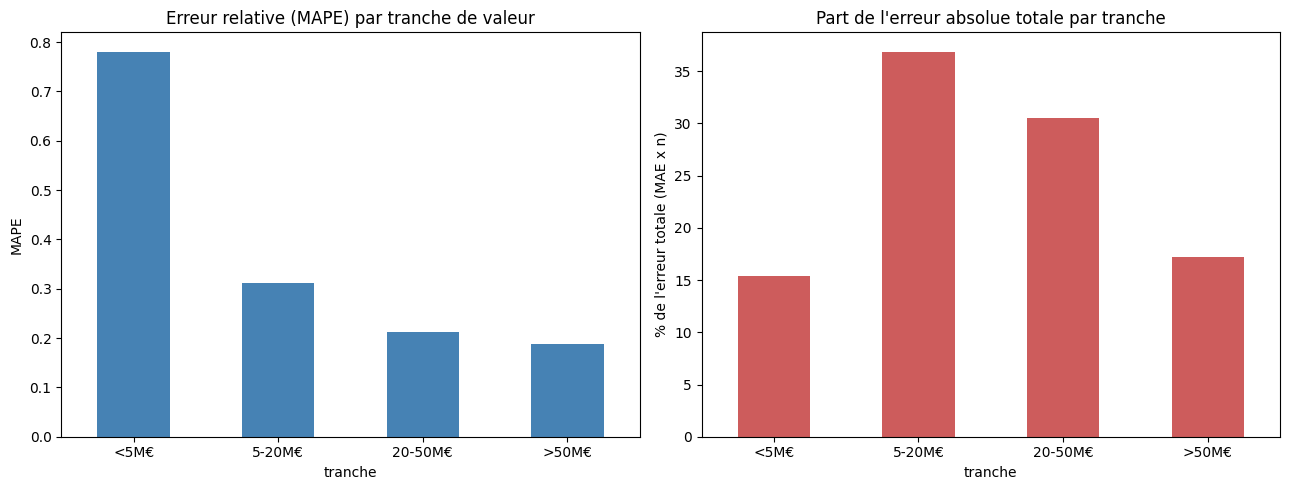

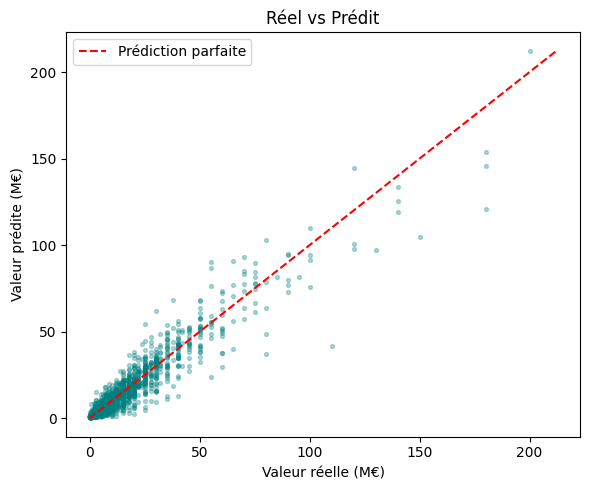

In [40]:
synthese_tranches = analyser_erreurs_par_tranches(
    y_test=data["y_test"],
    meilleure_prediction_test=pred_test_stack,
    random_state=RANDOM_STATE,
)

#### B3.4 — Feature importance (CatBoost)

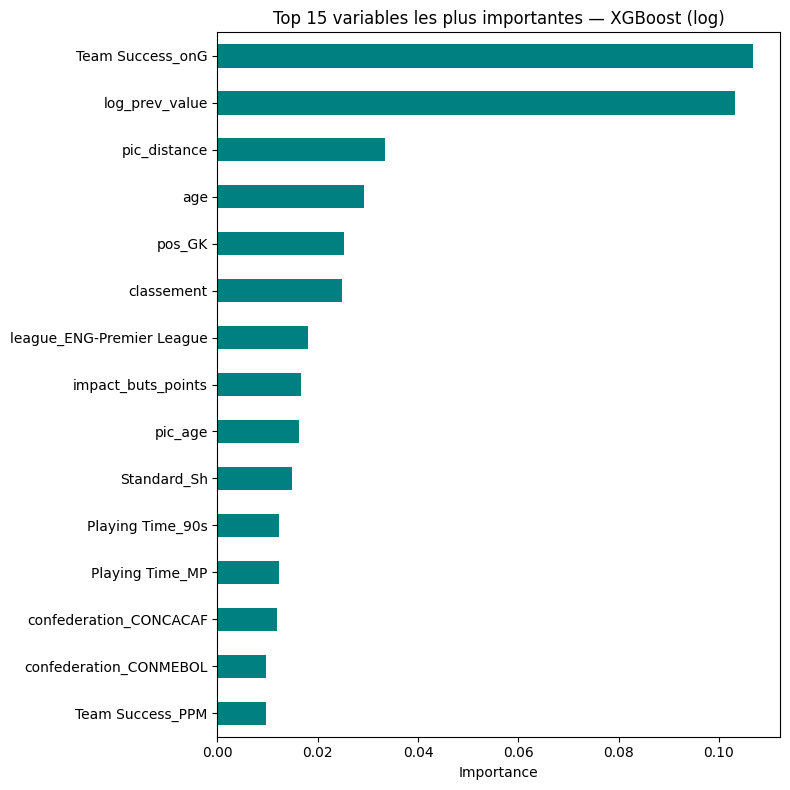

Team Success_onG             0.106831
log_prev_value               0.103282
pic_distance                 0.033419
age                          0.029240
pos_GK                       0.025262
classement                   0.024925
league_ENG-Premier League    0.017979
impact_buts_points           0.016584
pic_age                      0.016198
Standard_Sh                  0.014831
Playing Time_90s             0.012345
Playing Time_MP              0.012208
confederation_CONCACAF       0.011969
confederation_CONMEBOL       0.009655
Team Success_PPM             0.009609
dtype: float32


In [41]:
imp_xgb = afficher_feature_importances(
    modele=modeles_tuned_log["XGBoost (log)"],
    feature_names=data["X_train"].columns,
    top_n=15,
    nom_modele="XGBoost (log)",
    color="teal"
)

### B4 : Normalisation / Standardisation de la variable cible

**Ce qu'on teste :** une transformation de la valeur marchande différente de `log1p` améliore-t-elle les performances ?

**Ce qui varie ici :** la transformation de la cible.  
**Ce qui reste fixe :** pipeline Bloc A, mêmes hyperparamètres XGBoost, même test.

Pour isoler l'effet de la transformation seule, on utilise le **même XGBoost** sans retuner. Ensuite, on retune avec la meilleure transformation pour voir son plein potentiel.

| Transformation | Description 
|---|---
| Brute | Aucune 
| `log1p` | log(1+y) 
| `log10` | log₁₀(y) 
| `sqrt` | √y
| Yeo-Johnson | Transformation optimale MLE 
| MinMax [0,1] | Normalisation linéaire
| Rang centile | Quantile uniforme

#### B4.1 : Visualisation des distributions

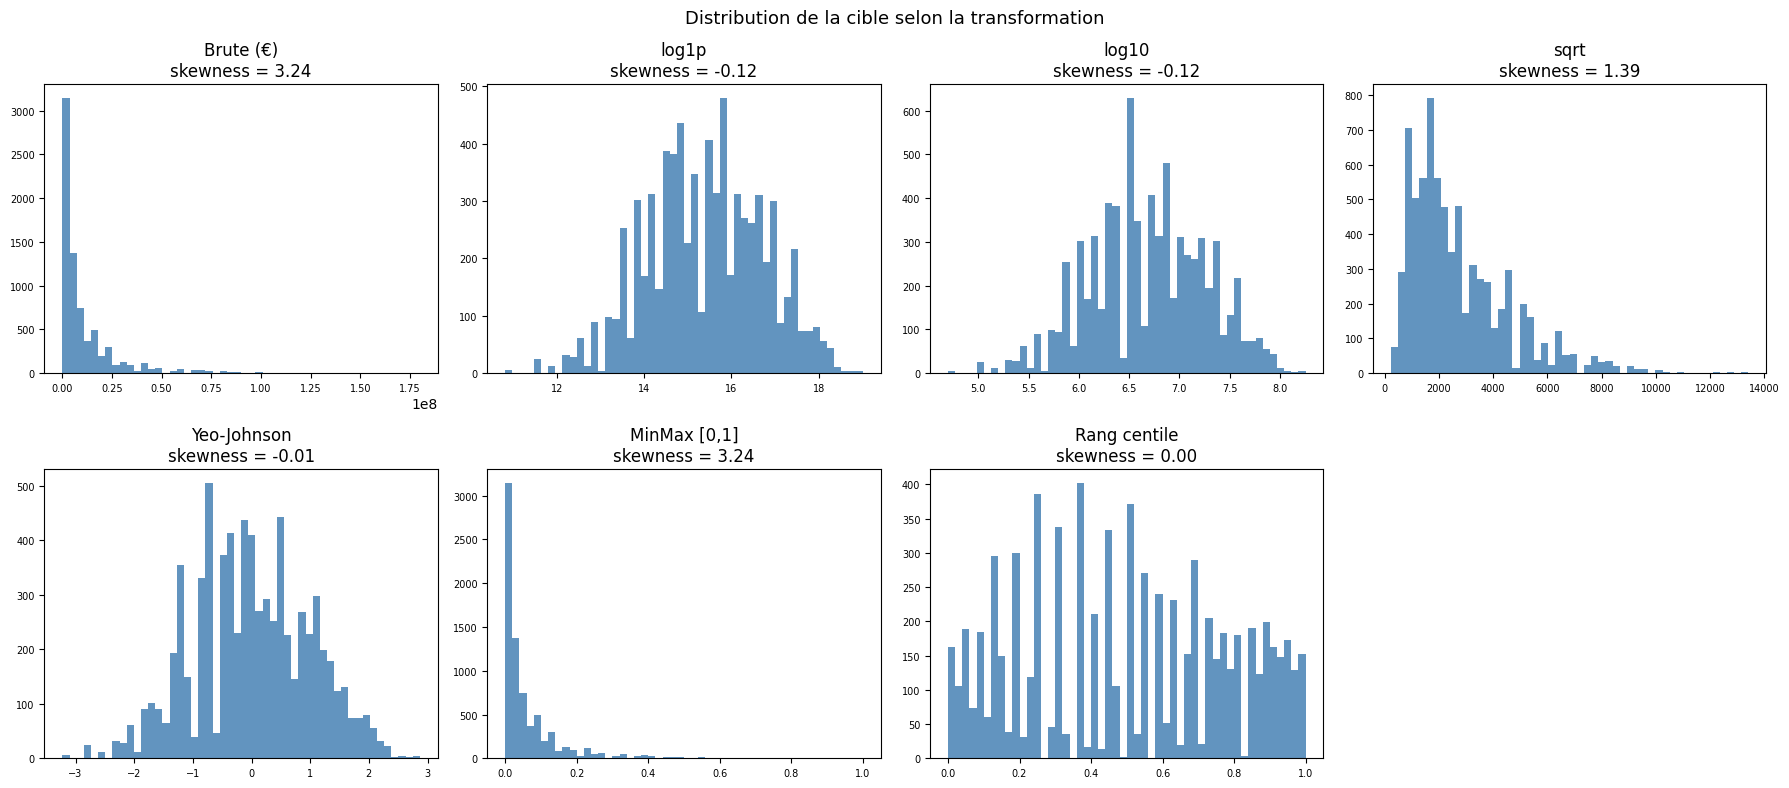

Statistiques de la cible brute :
count    7.404000e+03
mean     1.084476e+07
std      1.553714e+07
min      5.000000e+04
25%      2.000000e+06
50%      5.000000e+06
75%      1.400000e+07
max      1.800000e+08
Name: market_value_in_eur, dtype: float64


In [42]:
dict_transformations = analyser_transformations_cible(
    y_train=data["y_train"], random_state=RANDOM_STATE
)

#### B4.2 : Définition des transformations et fonctions inverses

Pour chaque transformation, on définit :
- `transform(y)` : passe les euros en espace de modélisation
- `inverse(y_pred)` : retransforme les prédictions en euros pour le calcul des métriques

In [43]:
transformations = preparer_transformations_cible(
    y_train=data["y_train"], random_state=RANDOM_STATE
)

# Exemple d'application
y_train_log = transformations["log1p (baseline)"]["transform"](data["y_train"])
y_train_recup = transformations["log1p (baseline)"]["inverse"](y_train_log)

7 transformations définies.


#### B4.3 : Entraînement et évaluation pour chaque transformation

In [46]:
resultats, predictions_test = evaluer_transformations_stacking(
    transformations=transformations,
    modeles_dict=modeles_tuned_log,
    data=data,
    sample_weights_train=sample_weights_train,
    cv=5,
)

print("\nSynthèse comparative du stacking par transformation")
print(resultats)


--- Brute (Stacking OOF) ---
  Aucune transformation. MAE en euros bruts....
  → MAPE: 55.91% | R²: 0.8938 | MAE:  3,318,780€ | RMSE_log: 1.6503

--- log1p (baseline) (Stacking OOF) ---
  log(1+y) — transformation de référence. Compresse l'échelle....
  → MAPE: 40.37% | R²: 0.8919 | MAE:  3,305,695€ | RMSE_log: 0.5276

--- log10 (Stacking OOF) ---
  log10(y) — espace plus lisible (6 = 1M€, 7 = 10M€)....
  → MAPE: 40.37% | R²: 0.8911 | MAE:  3,308,364€ | RMSE_log: 0.5277

--- sqrt (Stacking OOF) ---
  Racine carrée — compression plus douce que le log....
  → MAPE: 45.03% | R²: 0.8947 | MAE:  3,189,414€ | RMSE_log: 0.5235

--- Yeo-Johnson (Stacking OOF) ---
  Box-Cox généralisée optimisée par maximum de vraisemblance....
  → MAPE: 40.47% | R²: 0.8935 | MAE:  3,283,755€ | RMSE_log: 0.5242

--- MinMax [0,1] (Stacking OOF) ---
  Normalisation dans [0,1]. Sensible aux outliers....
  → MAPE: 54.25% | R²: 0.8937 | MAE:  3,303,693€ | RMSE_log: 1.5702

--- Rang centile [0,1] (Stacking OOF) ---


#### B4.4 : Tableau comparatif par MAPE croissant

=== CLASSEMENT PAR MAPE (↓ meilleur) ===
                               MAE            RMSE    MAPE      R² RMSE_log
Transformation                                                             
log10                  3,308,364 €     6,165,911 €  40.37%  0.8911   0.5277
log1p (baseline)       3,305,695 €     6,141,086 €  40.37%  0.8919   0.5276
Yeo-Johnson            3,283,755 €     6,096,243 €  40.47%  0.8935   0.5242
sqrt                   3,189,414 €     6,062,858 €  45.03%  0.8947   0.5235
Rang centile [0,1]     5,022,577 €    15,225,618 €  47.05%  0.3358   0.5670
MinMax [0,1]           3,303,693 €     6,089,591 €  54.25%  0.8937   1.5702
Brute                  3,318,780 €     6,088,945 €  55.91%  0.8938   1.6503


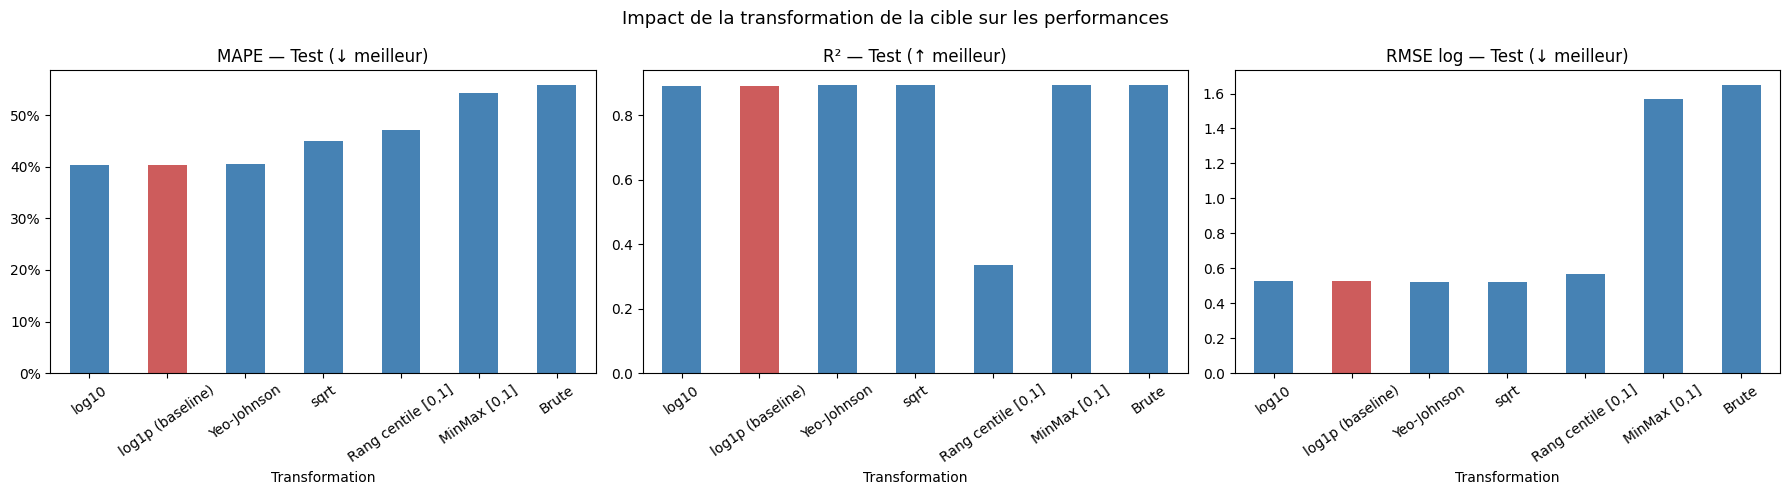

,MAE,RMSE,MAPE,R²,RMSE_log
Transformation,,,,,
log10,3.308364e+06,6.165911e+06,0.403659,0.891064,0.527697
log1p (baseline),3.305695e+06,6.141086e+06,0.403688,0.891939,0.527568
Yeo-Johnson,3.283755e+06,6.096243e+06,0.404720,0.893512,0.524182
sqrt,3.189414e+06,6.062858e+06,0.450270,0.894675,0.523464
"Rang centile [0,1]",5.022577e+06,1.522562e+07,0.470505,0.335756,0.566997
"MinMax [0,1]",3.303693e+06,6.089591e+06,0.542461,0.893744,1.570189
Brute,3.318780e+06,6.088945e+06,0.559066,0.893766,1.650341


In [52]:
afficher_synthese_transformations(resultats)

#### B4.5 : Analyse par tranche de valeur

=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===
Transformation                     <5M€   5–20M€  20–50M€    >50M€
-------------------------------------------------------------------
Brute                             88.8%    30.5%    20.7%    17.9%
log1p (baseline)                  53.6%    32.6%    21.7%    19.7%
log10                             53.7%    32.5%    21.8%    19.8%
sqrt                              65.6%    30.5%    20.5%    18.5%
Yeo-Johnson                       54.1%    32.3%    21.5%    19.5%
MinMax [0,1]                      85.3%    30.5%    20.6%    18.1%
Rang centile [0,1]                62.2%    31.2%    30.9%    69.3%


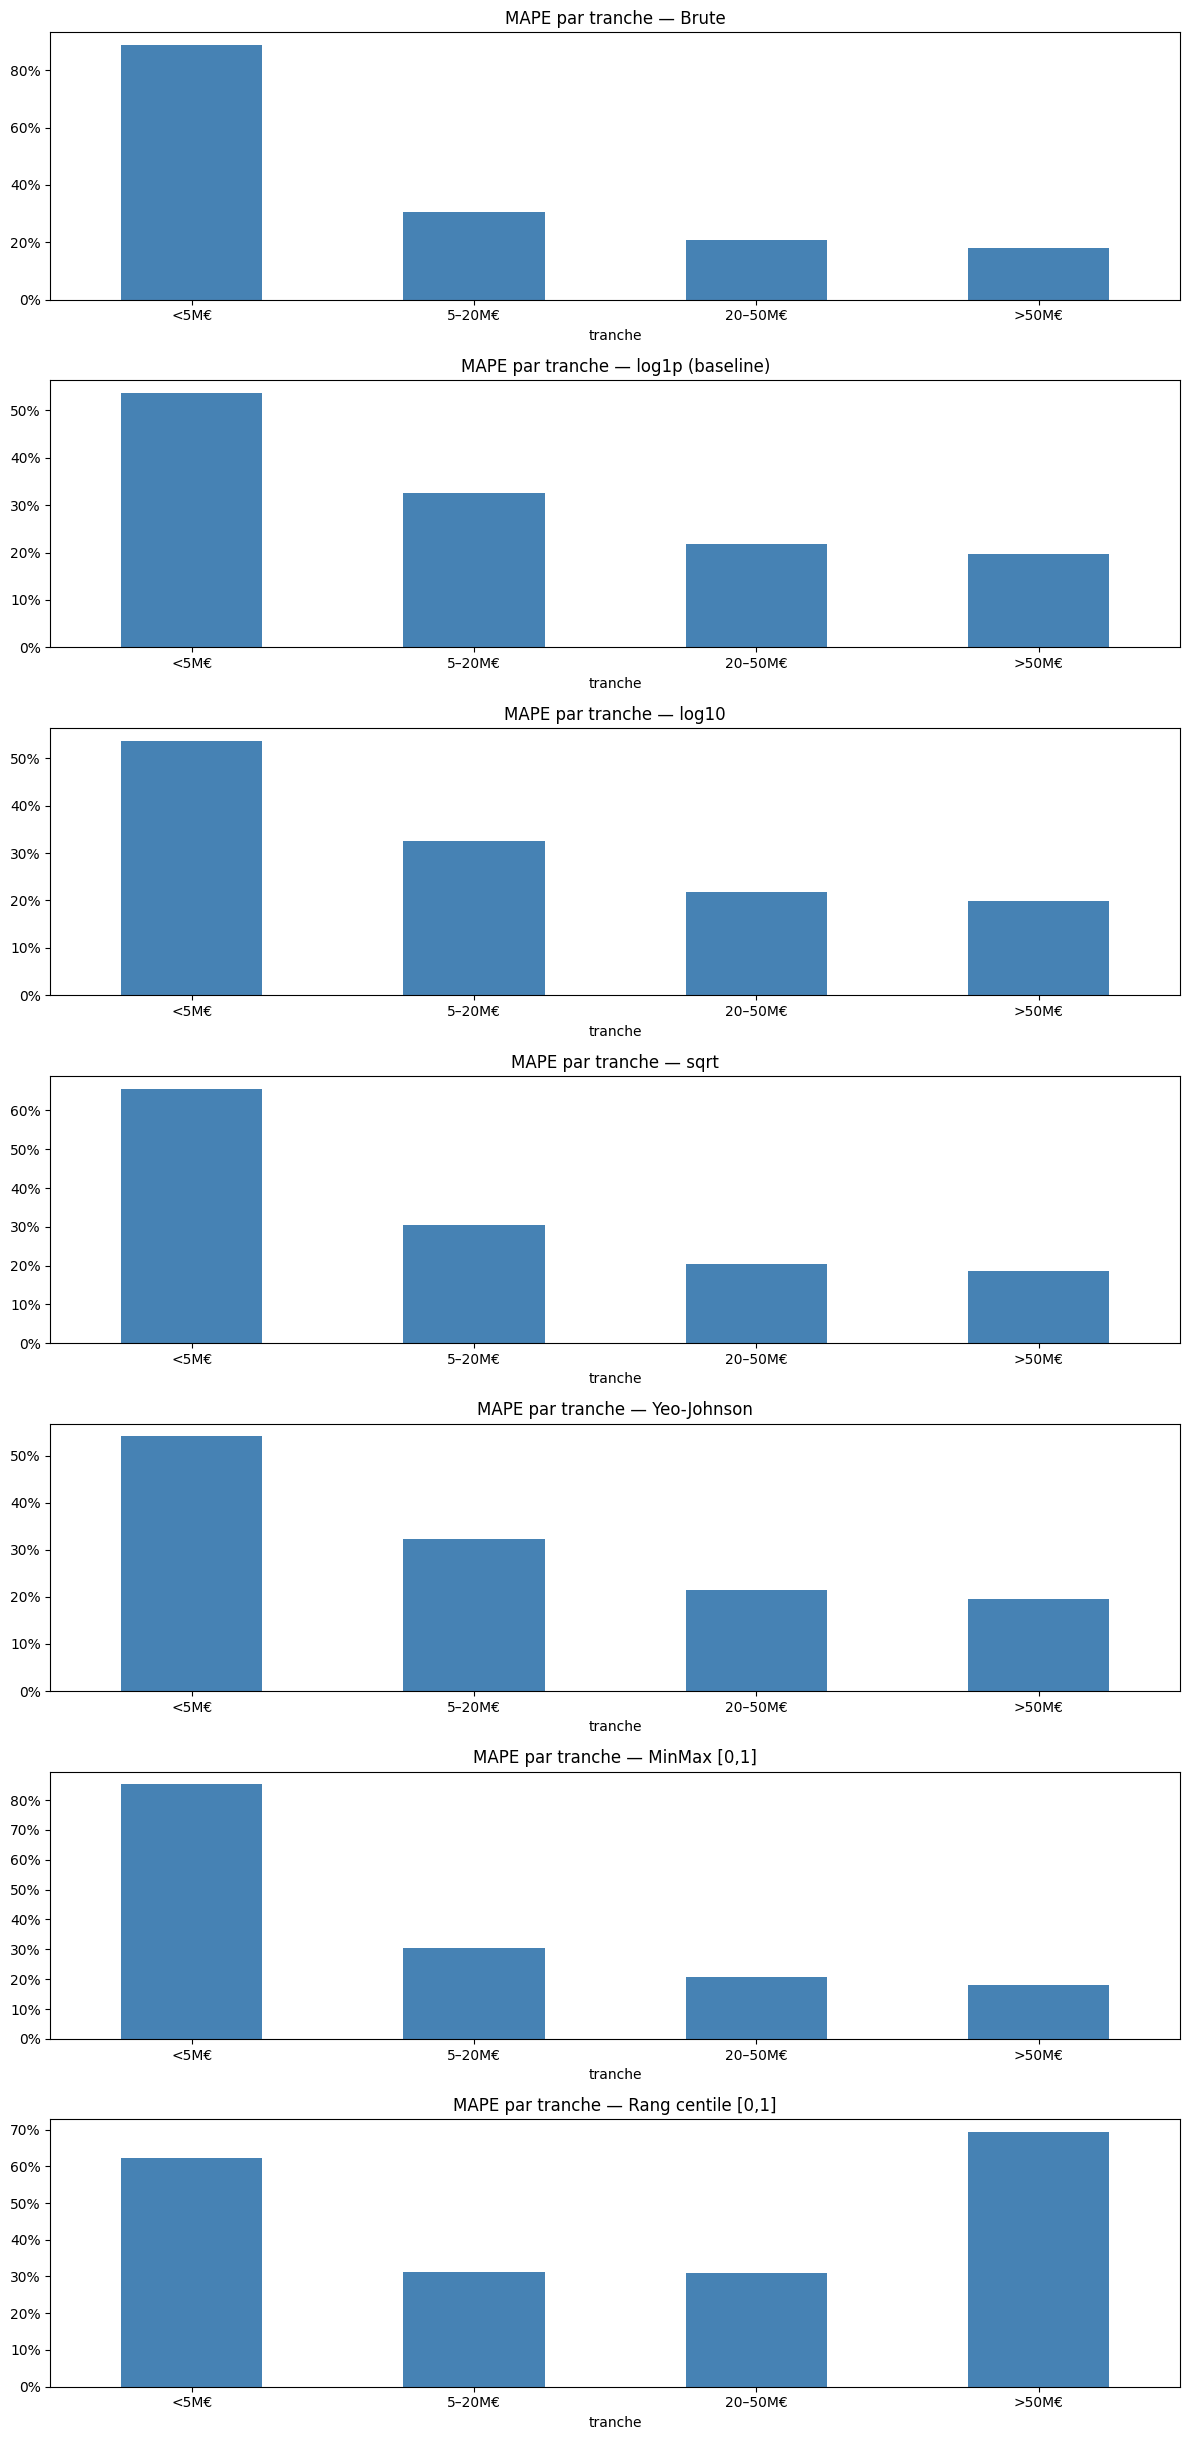

,<5M€,5–20M€,20–50M€,>50M€
Transformation,,,,
Brute,0.888070,0.305152,0.207237,0.179317
log1p (baseline),0.536489,0.325765,0.217389,0.197445
log10,0.536716,0.325009,0.218143,0.197829
sqrt,0.656326,0.304784,0.205039,0.185223
Yeo-Johnson,0.541429,0.323136,0.215489,0.195021
"MinMax [0,1]",0.852822,0.305273,0.206014,0.180603
"Rang centile [0,1]",0.622201,0.312244,0.308771,0.692696


In [57]:
analyser_mape_par_tranches(predictions_test=predictions_test, y_test=data["y_test"])

#### B4.6 : Tuning et Stacking OOF avec la meilleure transformation

On identifie la transformation qui minimise le MAPE, puis on retune XGBoost + LightGBM + CatBoost avec cette transformation et on construit le Stacking OOF final pour voir son plein potentiel.

In [ ]:
best_transfo_data = preparer_meilleure_transformation(
    df_res=resultats,
    transformations=transformations,
    y_train=data["y_train"],
    y_val=data.get("y_val", data["y_train"]),  # Fallback si y_val est optionnel
    y_test=data["y_test"],
    metric="MAPE",
)

# Récupération des cibles transformées pour le tuning ultérieur :
y_tr_best = best_transfo_data["y_tr_best"]
y_te_best = best_transfo_data["y_te_best"]

=== SÉLECTION DE LA MEILLEURE TRANSFORMATION (MAPE) ===
Meilleure transformation : log10
MAPE : 40.37%
R²   : 0.8911
MAE  :  3,308,364 €

Distribution de la cible transformée Train (log10) :
count    7404.000000
mean        6.690328
std         0.576314
min         4.698970
25%         6.301030
50%         6.698970
75%         7.146128
max         8.255273
Name: market_value_in_eur, dtype: float64
Skewness : -0.116



In [83]:
# On récupère la meilleure transformation sélectionnée
transfo_selected = best_transfo_data["transfo"]

study_xgb_best = optuna.create_study(direction="minimize")
study_xgb_best.optimize(
    lambda trial: tune_xgb(
        model_class=XGBRegressor,
        trial=trial,
        transfo=transfo_selected,
        X_train=X_train,
        y_train=data["y_train"],
        X_val=X_val,
        y_val=data["y_val"],
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres XGBoost :", study_xgb_best.best_params)

Best trial: 0. Best value: 5.71369e+06: 100%|██████████| 1/1 [00:18<00:00, 18.06s/it]

Meilleurs hyperparamètres XGBoost : {'n_estimators': 2500, 'max_depth': 6, 'learning_rate': 0.006816429835602687, 'subsample': 0.7382833680793817, 'colsample_bytree': 0.6230728542005572, 'min_child_weight': 7.165642919482532, 'reg_alpha': 0.00018748408151540128, 'reg_lambda': 0.0005067869810023269}


In [84]:
study_cat_best = optuna.create_study(direction="minimize")
study_cat_best.optimize(
    lambda trial: tune_catboost(
        model_class=CatBoostRegressor,
        trial=trial,
        transfo=transfo_selected,
        X_train=X_train,
        y_train=data["y_train"],
        X_val=X_val,
        y_val=data["y_val"],
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres CatBoost :", study_cat_best.best_params)

Best trial: 0. Best value: 6.56857e+06: 100%|██████████| 1/1 [00:04<00:00,  4.01s/it]

Meilleurs hyperparamètres CatBoost : {'learning_rate': 0.153913357416331, 'iterations': 3500, 'depth': 7, 'l2_leaf_reg': 2.2774795832213672, 'subsample': 0.8179666772693013}


In [85]:
study_lgbm_best = optuna.create_study(direction="minimize")
study_lgbm_best.optimize(
    lambda trial: tune_lgbm(
        model_class=LGBMRegressor,
        trial=trial,
        transfo=transfo_selected,
        X_train=X_train,
        y_train=data["y_train"],
        X_val=X_val,
        y_val=data["y_val"],
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres LightGBM :", study_lgbm_best.best_params)

Best trial: 0. Best value: 6.40697e+06: 100%|██████████| 1/1 [00:04<00:00,  4.72s/it]

Meilleurs hyperparamètres LightGBM : {'n_estimators': 2750, 'num_leaves': 61, 'max_depth': 4, 'learning_rate': 0.019480403391039527, 'subsample': 0.5497282044905292, 'colsample_bytree': 0.6303327834095198, 'reg_alpha': 0.0008720142627223216, 'reg_lambda': 0.03552129949961494}


In [94]:
transfo_selected

{'transform': <function tests_modelisation.preparer_transformations_cible.<locals>.<lambda>(y)>,
 'inverse': <function tests_modelisation.preparer_transformations_cible.<locals>.<lambda>(y)>,
 'description': 'log10(y) — espace plus lisible (6 = 1M€, 7 = 10M€).'}

In [97]:
# Instanciation de tes modèles avec les meilleurs hyperparamètres Optuna
modeles_f = {
    "XGBoost": XGBRegressor(**study_xgb_best.best_params, tree_method="hist",
                            enable_categorical=True, objective="reg:squarederror",
                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(**study_lgbm_best.best_params, random_state=RANDOM_STATE,
                              n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(**study_cat_best.best_params, bootstrap_type="Bernoulli",
                                  random_state=RANDOM_STATE, verbose=0),
}

# Lancement du pipeline complet
out_stacking = entrainer_et_evaluer_stacking_tuned(
    modeles_dict=modeles_f,
    transfo_dict=transformations,
    meilleure_transfo_label=best_transfo_data["nom"],
    data=data,
    sample_weights_train=sample_weights_train,
    cv=5,
    n_jobs=-1,
    evaluer_fn=evaluer_complet,
)


resultats_nouveau = pd.DataFrame([out_stacking["resultat"]])
resultats = pd.concat([resultats, resultats_nouveau], ignore_index=True)

Génération OOF...
  XGBoost: OOF MAPE = 42.72%
  LightGBM: OOF MAPE = 43.62%
  CatBoost: OOF MAPE = 44.38%
Poids méta : {'XGBoost': np.float64(0.54), 'LightGBM': np.float64(0.106), 'CatBoost': np.float64(0.367)}

=== RÉSULTAT FINAL (Tuné + Stack (log10)) ===
  MAPE     : 40.44%
  R²       : 0.8847
  MAE      :    3,337,161 €
  RMSE_log : 0.5280


#### B4.7 : Résultat final

In [103]:
# Modèle de référence optionnel
ref = {
    "Transformation": "log1p — modèle référence (tuné)",
    "MAPE": 0.3857,
    "R²": 0.880,
    "MAE": 3_340_118,
    "RMSE": None,
    "RMSE_log": 0.552,
}

# Appel de la fonction
df_classement_clean = afficher_classement_final(
    resultats=resultats, reference=ref, sort_by="MAPE", ascending=True
)

=== CLASSEMENT FINAL ===
                                   MAPE      R²             MAE RMSE_log
Transformation                                                          
log1p — modèle référence (tuné)  38.57%  0.8800     3,340,118 €   0.5520
log10                            40.37%  0.8911     3,308,364 €   0.5277
log1p (baseline)                 40.37%  0.8919     3,305,695 €   0.5276
Tuné + Stack (log10)             40.44%  0.8847     3,337,161 €   0.5280
Yeo-Johnson                      40.47%  0.8935     3,283,755 €   0.5242
sqrt                             45.03%  0.8947     3,189,414 €   0.5235
Rang centile [0,1]               47.05%  0.3358     5,022,577 €   0.5670
MinMax [0,1]                     54.25%  0.8937     3,303,693 €   1.5702
Brute                            55.91%  0.8938     3,318,780 €   1.6503


### B5 : Retrait des valeurs extrêmes

**Ce qu'on teste :** retirer les valeurs marchandes extrêmes du train améliore-t-il les performances ?

**Ce qui varie ici :** le filtrage du train (seuil IQR).  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test intouché.

**Hypothèse :** les joueurs > ~80M€ sont valorisés par des facteurs non capturés dans les stats (réputation médiatique, rareté, contexte de mercato). Leur présence dans le train peut biaiser l'apprentissage.

#### B5.1 : Chargement et identification des outliers

In [44]:
df_train_initial = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val_initial   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test_initial  = pd.read_csv("../data_finale/featuring/test_featured.csv")

# Calcul des quartiles et de l'IQR uniquement sur le TRAIN
Q1 = df_train_initial['market_value_in_eur'].quantile(0.25)
Q3 = df_train_initial['market_value_in_eur'].quantile(0.75)
IQR = Q3 - Q1

# Définition du seuil supérieur uniquement
# (Pas besoin de seuil inférieur puisqu'on garde tout ce qui est petit)
seuil_superieur = Q3 + 1.5 * IQR

# Filtrage : on ne garde que ce qui est INFÉRIEUR ou ÉGAL au seuil maximum
df_train_b5 = df_train_initial[df_train_initial['market_value_in_eur'] <= seuil_superieur]
df_val_b5   = df_val_initial[df_val_initial['market_value_in_eur'] <= seuil_superieur]
df_test_b5  = df_test_initial[df_test_initial['market_value_in_eur'] <= seuil_superieur]

# Vérification du nombre de lignes supprimées
print(f"Seuil max appliqué : {seuil_superieur:.2f}")
print(f"Lignes supprimées dans Train : {len(df_train_initial) - len(df_train_b5)}")
print(f"Lignes supprimées dans Val   : {len(df_val_initial) - len(df_val_b5)}")
print(f"Lignes supprimées dans Test  : {len(df_test_initial) - len(df_test_b5)}")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train_b5 = df_train_b5.dropna(subset=[colonne_cible])
df_val_b5   = df_val_b5.dropna(subset=[colonne_cible])
df_test_b5  = df_test_b5.dropna(subset=[colonne_cible])

Seuil max appliqué : 32000000.00
Lignes supprimées dans Train : 570
Lignes supprimées dans Val   : 224
Lignes supprimées dans Test  : 172


#### B5.2 : Préparation des jeux X / y

In [47]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]
# On supprime uniquement les colonnes qui existent réellement
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train_b5 = df_train_b5.drop(columns=colonnes_nor, errors="ignore")
df_val_b5   = df_val_b5.drop(columns=colonnes_nor, errors="ignore")
df_test_b5  = df_test_b5.drop(columns=colonnes_nor, errors="ignore")

X_train_b5 = df_train_b5.drop(columns=cols_a_supprimer)
y_train_b5 = df_train_b5[colonne_cible]

X_val_b5   = df_val_b5.drop(columns=cols_a_supprimer)
y_val_b5   = df_val_b5[colonne_cible]

X_test_b5  = df_test_b5.drop(columns=cols_a_supprimer)
y_test_b5  = df_test_b5[colonne_cible]

# Cibles log
y_train_log_b5 = np.log1p(y_train_b5)
y_val_log_b5   = np.log1p(y_val_b5)
y_test_log_b5  = np.log1p(y_test_b5)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
# w_i = 1 / log1p(y_i)  → les joueurs à faible valeur pèsent autant que les stars
sample_weights_train_b5 = 1 / np.log1p(y_train_b5)
sample_weights_train_b5 = sample_weights_train_b5 / sample_weights_train_b5.mean()

print(f"X_train : {X_train_b5.shape} | X_val : {X_val_b5.shape} | X_test : {X_test_b5.shape}")

X_train : (6834, 153) | X_val : (2207, 153) | X_test : (1579, 153)


#### B5.3 : Tuning des hyperparamètres

In [48]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "enable_categorical": True,
        "objective":         "reg:squarederror",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    
    model = XGBRegressor(**params)
    
    # Entraînement classique sur la cible log
    model.fit(X_train_b5, y_train_log_b5, sample_weight=sample_weights_train_b5)
    
    # On fait la prédiction en log
    preds_log = model.predict(X_val_b5)
    
    # On calcule le RMSE directement sur les logs (y_val_log_b5) pour la stabilité d'Optuna
    return np.sqrt(mean_squared_error(y_val_log_b5, preds_log))

print("--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

# Pour afficher un vrai MAPE business à la fin (calculé hors de la boucle) :
best_model = XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True, random_state=RANDOM_STATE)
best_model.fit(X_train_b5, y_train_log_b5, sample_weight=sample_weights_train_b5)
final_preds = np.expm1(best_model.predict(X_val_b5))
final_mape = mean_absolute_percentage_error(y_val_b5, final_preds)

print(f"Meilleur RMSE log val : {study_xgb.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape:.4f}")
print(f"Params : {study_xgb.best_params}")

--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 29. Best value: 0.563853: 100%|██████████| 30/30 [09:17<00:00, 18.58s/it]


Meilleur RMSE log val : 0.5639
MAPE réel correspondant : 0.4463
Params : {'n_estimators': 1750, 'max_depth': 8, 'learning_rate': 0.01009603091061803, 'subsample': 0.7989585685491069, 'colsample_bytree': 0.8434019237411954, 'min_child_weight': 3.644834583817771, 'reg_alpha': 0.01831370869459229, 'reg_lambda': 0.05007353790580164}


In [49]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train_b5, y_train_log_b5, sample_weight=sample_weights_train_b5)
    
    # MODIFICATION : On reste en log pour la prédiction
    preds_log = model.predict(X_val_b5)
    
    # MODIFICATION : On renvoie le RMSE calculé sur les logs
    return np.sqrt(mean_squared_error(y_val_log_b5, preds_log))

# Nettoyage des textes des prints pour l'affichage
print("--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train_b5, y_train_log_b5, sample_weight=sample_weights_train_b5)
final_preds_lgbm = np.expm1(best_lgbm.predict(X_val_b5))
final_mape_lgbm = mean_absolute_percentage_error(y_val_b5, final_preds_lgbm)

print(f"Meilleur RMSE log val : {study_lgbm.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_lgbm:.4f}")
print(f"Params : {study_lgbm.best_params}")

--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---


Best trial: 21. Best value: 0.567991: 100%|██████████| 30/30 [06:02<00:00, 12.08s/it]


Meilleur RMSE log val : 0.5680
MAPE réel correspondant : 0.4479
Params : {'n_estimators': 2000, 'num_leaves': 69, 'max_depth': 11, 'learning_rate': 0.005003553745072824, 'subsample': 0.7512506634364409, 'colsample_bytree': 0.7330008178216458, 'reg_alpha': 0.00010219723819313146, 'reg_lambda': 0.0063606173031882365}


In [50]:
def objective_catboost(trial):
    params = {
        "iterations":             trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                  trial.suggest_int("depth", 4, 8),
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":              trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":           RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train_b5, y_train_log_b5,
        eval_set=(X_val_b5, y_val_log_b5),
        sample_weight=sample_weights_train_b5,
        verbose=False
    )
    
    # MODIFICATION : On reste sur l'échelle des logs pour la prédiction
    preds_log = model.predict(X_val_b5)
    
    # MODIFICATION : On calcule et renvoie le RMSE directement sur les logs (y_val_log)
    return np.sqrt(mean_squared_error(y_val_log_b5, preds_log))

# Nettoyage des textes et des prints pour l'affichage
print("--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_cat = CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli", random_state=RANDOM_STATE, verbose=0)
best_cat.fit(X_train_b5, y_train_log_b5, sample_weight=sample_weights_train_b5, verbose=False)
final_preds_cat = np.expm1(best_cat.predict(X_val_b5))
final_mape_cat = mean_absolute_percentage_error(y_val_b5, final_preds_cat)

print(f"Meilleur RMSE log val : {study_cat.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_cat:.4f}")
print(f"Params : {study_cat.best_params}")

--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 8. Best value: 0.560647: 100%|██████████| 30/30 [05:20<00:00, 10.68s/it]


Meilleur RMSE log val : 0.5606
MAPE réel correspondant : 0.4420
Params : {'iterations': 3000, 'depth': 8, 'learning_rate': 0.023833577968822288, 'l2_leaf_reg': 2.532778657149112, 'subsample': 0.8133748652604686}


#### B5.4 : Modèles finaux et évaluation validation

In [51]:
xgb_final = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("=== Évaluation VALIDATION ===")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train_b5, y_train_log_b5, X_val_b5, y_val_b5, w=sample_weights_train_b5)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

=== Évaluation VALIDATION ===
  XGBoost      | MAPE : 44.63% | MAE :    2,324,137 € | R² : 0.7329 | R²adj : 0.7130
  LightGBM     | MAPE : 44.79% | MAE :    2,343,589 € | R² : 0.7285 | R²adj : 0.7083
  CatBoost     | MAPE : 44.61% | MAE :    2,334,748 € | R² : 0.7338 | R²adj : 0.7140

Classement validation (MAPE croissant) :
                   MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost  2.334748e+06  3.924882e+06  0.446091  0.733840   0.714004
XGBoost   2.324137e+06  3.931499e+06  0.446343  0.732942   0.713039
LightGBM  2.343589e+06  3.964111e+06  0.447935  0.728493   0.708259


#### B5.5 : Stacking OOF

In [52]:
base_models = ["XGBoost", "LightGBM", "CatBoost"]

# OOF sur le train (cv=5)
print("Génération OOF predictions (cv=5)...")
oof_log = {}
for nom in base_models:
    modele = modeles_finaux[nom]
    oof    = cross_val_predict(modele, X_train_b5, y_train_log_b5, cv=5, n_jobs=-1)
    oof_log[nom] = oof
    print(f"  {nom:12s} | OOF MAE : {mean_absolute_error(y_train_b5, np.expm1(oof)):>12,.0f} € | OOF MAPE : {mean_absolute_percentage_error(y_train_b5, np.expm1(oof)):.2%}")

X_meta_train = pd.DataFrame(oof_log)

# Prédictions val & test (modèles ré-entraînés sur tout le train)
print("\nEntraînement final sur train complet...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train_b5, y_train_log_b5, eval_set=(X_val_b5, y_val_log_b5),
                   sample_weight=sample_weights_train_b5, verbose=False)
    else:
        modele.fit(X_train_b5, y_train_log_b5, sample_weight=sample_weights_train_b5)
    print(f"  {nom} : entraîné")

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val_b5)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test_b5) for nom in base_models}

X_meta_val  = pd.DataFrame(preds_val_log)
X_meta_test = pd.DataFrame(preds_test_log)

Génération OOF predictions (cv=5)...
  XGBoost      | OOF MAE :    2,248,936 € | OOF MAPE : 44.88%
  LightGBM     | OOF MAE :    2,245,360 € | OOF MAPE : 45.31%
  CatBoost     | OOF MAE :    2,229,574 € | OOF MAPE : 44.32%

Entraînement final sur train complet...
  XGBoost : entraîné
  LightGBM : entraîné
  CatBoost : entraîné


In [53]:
# Méta-modèle : régression linéaire à coefficients positifs (combinaison convexe)

meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log_b5)

print("Poids du méta-modèle (espace log) :")
for nom, w in zip(base_models, meta.coef_):
    print(f"  {nom:12s} : {w:.4f}")
print(f"  Intercept    : {meta.intercept_:.4f}")

# Prédictions finales (retransformation en euros)
pred_val_stack  = np.expm1(meta.predict(X_meta_val))
pred_test_stack = np.expm1(meta.predict(X_meta_test))

# Moyenne simple (baseline de comparaison)
pred_val_moy  = np.expm1(X_meta_val.mean(axis=1))
pred_test_moy = np.expm1(X_meta_test.mean(axis=1))

print("\nComparaison finale (Validation)")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val_b5, preds):.2%} | MAE : {mean_absolute_error(y_val_b5, preds):>12,.0f} € | R² : {r2_score(y_val_b5, preds):.4f}")

Poids du méta-modèle (espace log) :
  XGBoost      : 0.2870
  LightGBM     : 0.1087
  CatBoost     : 0.6270
  Intercept    : -0.3399

Comparaison finale (Validation)
  Stacking OOF    | MAPE : 43.86% | MAE :    2,266,778 € | R² : 0.7473
  Moyenne simple  | MAPE : 44.06% | MAE :    2,298,688 € | R² : 0.7373


#### B5.6 : Résultats finaux sur le test

In [54]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost"])),
]:
    mae  = mean_absolute_error(y_test_b5, preds)
    mape = mean_absolute_percentage_error(y_test_b5, preds)
    r2   = r2_score(y_test_b5, preds)
    n, p = len(y_test_b5), X_test_b5.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 41.54% | MAE :    2,553,181 € | R² : 0.7398
  Moyenne simple  | MAPE : 41.62% | MAE :    2,579,857 € | R² : 0.7321
  XGBoost seul    | MAPE : 42.08% | MAE :    2,587,704 € | R² : 0.7318
  LightGBM seul   | MAPE : 41.97% | MAE :    2,609,719 € | R² : 0.7293
  CatBoost seul   | MAPE : 42.51% | MAE :    2,642,953 € | R² : 0.7210

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Stacking OOF    0.415407  2.553181e+06  0.739798   0.711861
Moyenne simple  0.416170  2.579857e+06  0.732097   0.703333
LightGBM seul   0.419693  2.609719e+06  0.729251   0.700181
XGBoost seul    0.420754  2.587704e+06  0.731798   0.703001
CatBoost seul   0.425100  2.642953e+06  0.721019   0.691065


#### B5.7 : Analyse par tranche et visualisations

In [55]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5–20M€", "20–50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test_b5.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moy    =("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese["% joueurs"]       = synthese["n_joueurs"] / len(df_erreur) * 100
synthese["% erreur totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum()
    / df_erreur["erreur_abs"].sum() * 100
)
print(synthese.to_string())

         n_joueurs    valeur_moy           MAE      MAPE  % joueurs  % erreur totale
tranche                                                                             
<5M€           817  2.413250e+06  8.757894e+05  0.521565  51.741609        17.748353
5–20M€         586  1.178584e+07  3.469794e+06  0.311034  37.112096        50.435643
20–50M€        176  2.644886e+07  7.287804e+06  0.270126  11.146295        31.816005


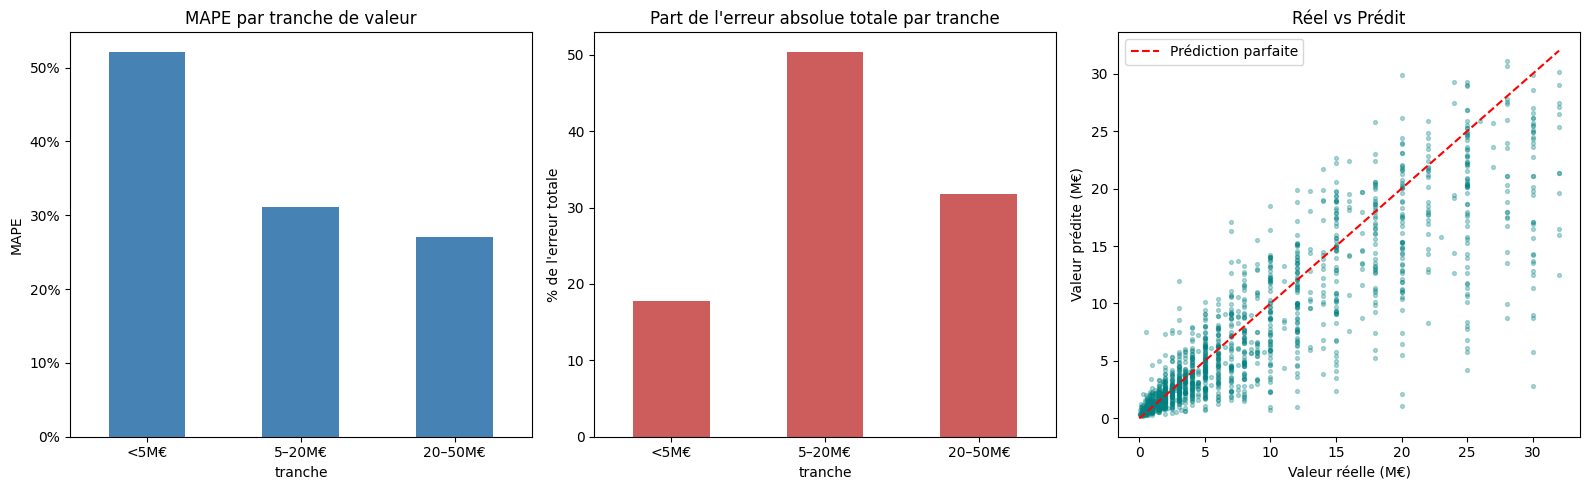

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — MAPE par tranche
synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2 — % erreur totale par tranche
synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale")
axes[1].tick_params(axis="x", rotation=0)

# Plot 3 — Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

#### B5.8 : Feature importance (CatBoost)

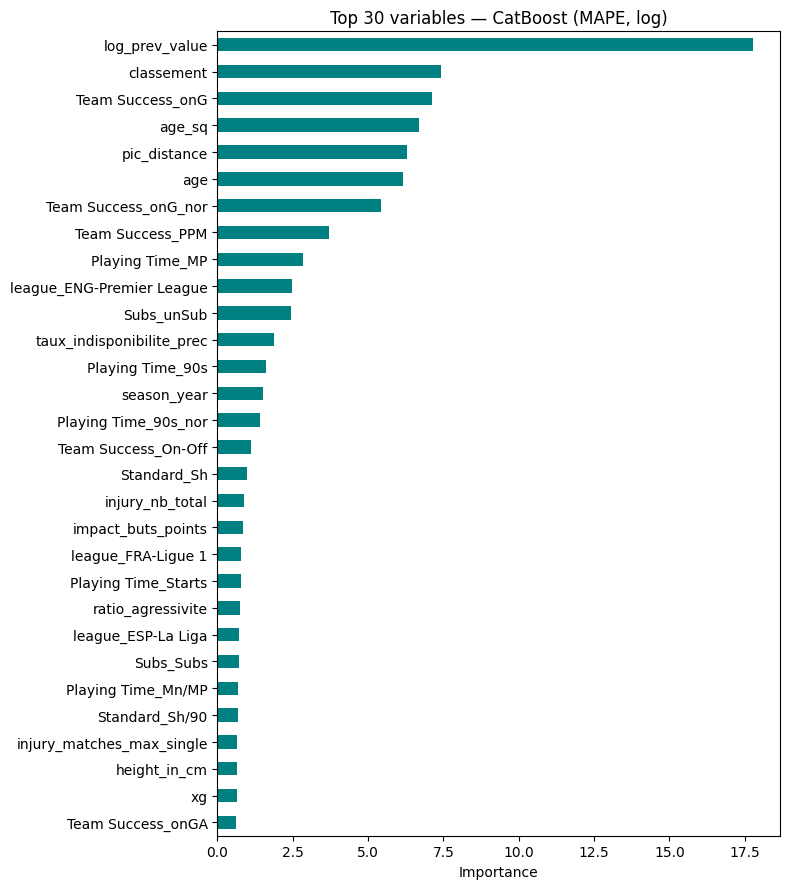


Top 30 :
log_prev_value               17.779854
classement                    7.430285
Team Success_onG              7.134786
age_sq                        6.672471
pic_distance                  6.282287
age                           6.156239
Team Success_onG_nor          5.440617
Team Success_PPM              3.687812
Playing Time_MP               2.843908
league_ENG-Premier League     2.479004
Subs_unSub                    2.431248
taux_indisponibilite_prec     1.885528
Playing Time_90s              1.619026
season_year                   1.527170
Playing Time_90s_nor          1.397200
Team Success_On-Off           1.118714
Standard_Sh                   0.977566
injury_nb_total               0.877609
impact_buts_points            0.838844
league_FRA-Ligue 1            0.787830
Playing Time_Starts           0.780382
ratio_agressivite             0.740526
league_ESP-La Liga            0.729855
Subs_Subs                     0.727564
Playing Time_Mn/MP            0.685195
Standard_Sh/90 

In [57]:
importances = pd.Series(
    cat_final.get_feature_importance(),
    index=X_train_b5.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.head(30).sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 30 variables — CatBoost (MAPE, log)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 30 :")
print(importances.head(30).to_string())

### B6 : Réduction de dimensionnalité

**Ce qu'on teste :** réduire le nombre de features améliore-t-il les performances ?

**Ce qui varie ici :** le nombre et la sélection des features.  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test.

| Approche | Principe | Interprétabilité | Biais |
|---|---|---|---|
| **ACP 95%/99%/99.9%** | Composantes orthogonales classées par variance | Non | Non |
| **Sélection gain** top 50/75/100 | Features les plus importantes (XGBoost) | Oui | Haute cardinalité |
| **Permutation Importance** > 0/0.001/0.005 | Dégradation réelle si la feature est mélangée | Oui | Non biaisée |

#### B6.2 — Baseline de référence

On évalue d'abord le Stacking OOF **sans réduction** pour avoir un point de comparaison objectif. Toute approche qui fait moins bien que cette baseline n'apporte rien.

In [58]:
def rmse_log(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred,0,None))))

def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rl       = rmse_log(y_true, y_pred)
    n, p_    = len(y_true), 1
    return {"Label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape,
            "R²": r2, "RMSE_log": rl}

def entrainer_stack(X_tr, y_tr_log, X_val_, y_val_log_, X_te, y_val, w=None):
    """Entraîne XGB+LGBM+CAT + stacking OOF. Renvoie preds_val, preds_test."""
    xgb = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        tree_method="hist", enable_categorical=True,
                        objective="reg:squarederror",
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    lgbm = LGBMRegressor(n_estimators=1000, num_leaves=63, max_depth=6,
                          learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    cat  = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05,
                              l2_leaf_reg=3, bootstrap_type="Bernoulli",
                              random_state=RANDOM_STATE, verbose=0)
    modeles = {"XGBoost": xgb, "LightGBM": lgbm, "CatBoost": cat}
    kw = {"sample_weight": w} if w is not None else {}

    # OOF
    oof = {}
    for nom, m in modeles.items():
        oof[nom] = cross_val_predict(m, X_tr, y_tr_log, cv=5, n_jobs=-1)

    # Ré-entraînement
    for nom, m in modeles.items():
        if isinstance(m, CatBoostRegressor):
            m.fit(X_tr, y_tr_log, eval_set=(X_val_, y_val_log_), verbose=False, **kw)
        else:
            m.fit(X_tr, y_tr_log, **kw)

    X_meta_tr  = pd.DataFrame(oof)
    X_meta_val = pd.DataFrame({n: m.predict(X_val_) for n,m in modeles.items()})
    X_meta_te  = pd.DataFrame({n: m.predict(X_te)  for n,m in modeles.items()})

    meta = LinearRegression(positive=True)
    meta.fit(X_meta_tr, y_tr_log)

    return (np.expm1(meta.predict(X_meta_val)),
            np.expm1(meta.predict(X_meta_te)),
            modeles)

print("Entraînement baseline (sans réduction)...")
pred_val_base, pred_test_base, modeles_base = entrainer_stack(
    X_train, y_train_log, X_val, y_val_log, X_test, y_val, w=sample_weights_train)

res_base = evaluer_complet("Sans réduction", y_test, pred_test_base)
print(f"  MAPE : {res_base['MAPE']:.2%} | R² : {res_base['R²']:.4f} | RMSE_log : {res_base['RMSE_log']:.4f}")
resultats_comparaison = [res_base]

Entraînement baseline (sans réduction)...
  MAPE : 40.13% | R² : 0.8819 | RMSE_log : 0.5292


#### B6.2 : ACP (Analyse en Composantes Principales)

**Étapes :**
1. Imputation des NaN résiduels par la médiane (nécessaire avant StandardScaler)
2. Standardisation
3. Calcul de la variance expliquée cumulée
4. Test de 3 seuils : 95%, 99%, 99.9% de variance conservée

NaN restants — train: 0 | val: 0 | test: 0
Dimensions originales : 145 features
Composantes pour 95%  de variance : 80
Composantes pour 99%  de variance : 105
Composantes pour 99.9% de variance : 121


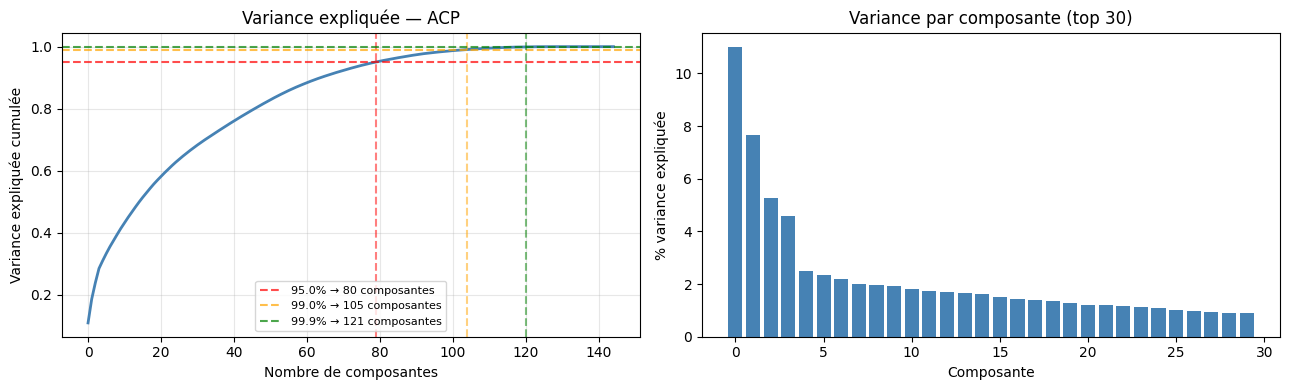

In [59]:
# Imputation des NaN résiduels (médiane par colonne, apprise sur le train)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f"NaN restants — train: {X_train_imp.isnull().sum().sum()} | val: {X_val_imp.isnull().sum().sum()} | test: {X_test_imp.isnull().sum().sum()}")

# Standardisation obligatoire avant ACP
scaler_acp = StandardScaler()
X_train_scaled = scaler_acp.fit_transform(X_train_imp)
X_val_scaled   = scaler_acp.transform(X_val_imp)
X_test_scaled  = scaler_acp.transform(X_test_imp)

# ACP — on cherche le nombre de composantes pour 95% de variance expliquée
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

variance_cumul = np.cumsum(pca_full.explained_variance_ratio_)
n_95  = np.argmax(variance_cumul >= 0.95) + 1
n_99  = np.argmax(variance_cumul >= 0.99) + 1
n_999 = np.argmax(variance_cumul >= 0.999) + 1

print(f"Dimensions originales : {X_train.shape[1]} features")
print(f"Composantes pour 95%  de variance : {n_95}")
print(f"Composantes pour 99%  de variance : {n_99}")
print(f"Composantes pour 99.9% de variance : {n_999}")

# Visualisation de la variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(variance_cumul, lw=2, color="steelblue")
for thresh, n, color in [(0.95, n_95, "red"), (0.99, n_99, "orange"), (0.999, n_999, "green")]:
    axes[0].axhline(thresh, linestyle="--", color=color, alpha=0.7,
                     label=f"{thresh:.1%} → {n} composantes")
    axes[0].axvline(n-1, linestyle="--", color=color, alpha=0.5)
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("Variance expliquée cumulée")
axes[0].set_title("Variance expliquée — ACP")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Variance par composante (top 30)
axes[1].bar(range(30), pca_full.explained_variance_ratio_[:30]*100,
             color="steelblue", edgecolor="none")
axes[1].set_xlabel("Composante")
axes[1].set_ylabel("% variance expliquée")
axes[1].set_title("Variance par composante (top 30)")
plt.tight_layout()
plt.show()

In [60]:
# Test avec 3 seuils de variance : 95%, 99%, 99.9%
for seuil, n_comp, label_acp in [
    (0.95,  n_95,  "ACP 95%"),
    (0.99,  n_99,  "ACP 99%"),
    (0.999, n_999, "ACP 99.9%"),
]:
    print(f"\n--- {label_acp} ({n_comp} composantes) ---")
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xtr_pca  = pca.fit_transform(X_train_scaled)
    Xval_pca = pca.transform(X_val_scaled)
    Xte_pca  = pca.transform(X_test_scaled)

    # Convertir en DataFrame pour compatibilité (les arbres n'ont pas besoin de noms)
    Xtr_pca  = pd.DataFrame(Xtr_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])
    Xval_pca = pd.DataFrame(Xval_pca, columns=[f"PC{i+1}" for i in range(n_comp)])
    Xte_pca  = pd.DataFrame(Xte_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])

    # y_val_log doit être réindexé
    y_val_log_arr = y_val_log.values

    pred_val_acp, pred_te_acp, _ = entrainer_stack(
        Xtr_pca, y_train_log.values, Xval_pca,
        pd.Series(y_val_log_arr), Xte_pca, y_val,
        w=sample_weights_train.values
    )
    res = evaluer_complet(label_acp, y_test.values, pred_te_acp)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- ACP 95% (80 composantes) ---
  MAPE : 53.06% | R² : 0.7946 | RMSE_log : 0.5996

--- ACP 99% (105 composantes) ---
  MAPE : 52.25% | R² : 0.7920 | RMSE_log : 0.6085

--- ACP 99.9% (121 composantes) ---
  MAPE : 52.38% | R² : 0.7887 | RMSE_log : 0.6033


#### B6.3 : Sélection par importance XGBoost (gain)

On entraîne un XGBoost rapide pour extraire l'importance par gain de chaque feature, puis on garde les top N les plus importantes.

⚠️ **Attention :** l'importance par gain est biaisée : elle tend à sur-estimer les features à haute cardinalité (comme les variables continues) par rapport aux variables binaires.

Features total : 145
Features avec importance > 0   : 134
Features avec importance > 0.01 (1%) : 12
Features avec importance > 0.005 (0.5%) : 27
Top 20 features :
log_prev_value               0.184462
Team Success_onG             0.169687
pos_GK                       0.063247
league_ENG-Premier League    0.044176
impact_buts_points           0.036734
classement                   0.034630
age                          0.025523
pic_age                      0.021139
Standard_Sh                  0.015872
league_FRA-Ligue 1           0.015001
injury_matches_max_single    0.014756
season_year                  0.010493
Team Success_PPM             0.009823
Standard_SoT                 0.009129
taux_indisponibilite_prec    0.009039
confederation_CONMEBOL       0.008673
Playing Time_MP              0.008125
sub_position_Right-Back      0.007833
Subs_unSub                   0.007596
est_polyvalent               0.006924


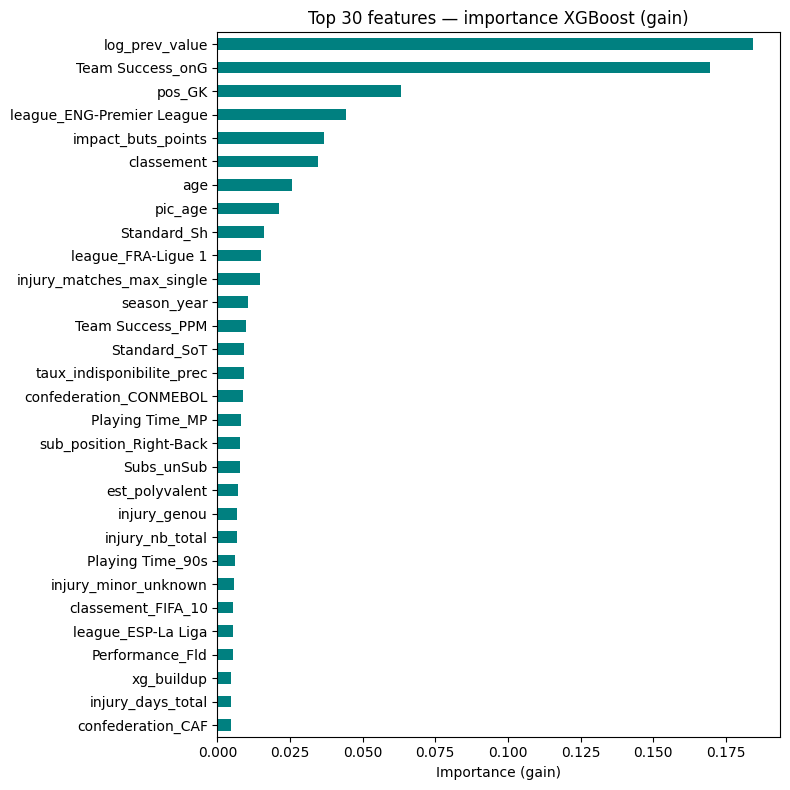

In [61]:
# Entraîner un XGBoost rapide pour obtenir les importances
selector_model = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
selector_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)

importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(f"Features total : {len(importances)}")
print(f"Features avec importance > 0   : {(importances > 0).sum()}")
print(f"Features avec importance > 0.01 (1%) : {(importances > 0.01).sum()}")
print(f"Features avec importance > 0.005 (0.5%) : {(importances > 0.005).sum()}")
print(f"Top 20 features :")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(30).sort_values().plot(kind="barh", ax=ax, color="teal", edgecolor="none")
ax.set_title("Top 30 features — importance XGBoost (gain)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

In [62]:
# Tester plusieurs seuils de sélection
for seuil_n, label_sfm in [(50, "SFM top 50"), (75, "SFM top 75"), (100, "SFM top 100")]:
    features_sel = importances.head(seuil_n).index.tolist()
    print(f"\n--- {label_sfm} ({len(features_sel)} features) ---")

    pred_val_sfm, pred_te_sfm, _ = entrainer_stack(
        X_train[features_sel], y_train_log, X_val[features_sel], y_val_log,
        X_test[features_sel], y_val, w=sample_weights_train
    )
    res = evaluer_complet(label_sfm, y_test, pred_te_sfm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- SFM top 50 (50 features) ---
  MAPE : 39.70% | R² : 0.8807 | RMSE_log : 0.5280

--- SFM top 75 (75 features) ---
  MAPE : 39.63% | R² : 0.8848 | RMSE_log : 0.5283

--- SFM top 100 (100 features) ---
  MAPE : 39.68% | R² : 0.8868 | RMSE_log : 0.5257


#### B6.4 : Permutation importance

La permutation importance mélange aléatoirement chaque feature une par une sur le jeu de **validation** (pas le train, mémorisé par les arbres) et mesure la dégradation de performance. Elle est **non biaisée** et capture l'impact réel sur les prédictions.

Calcul permutation importance (peut prendre 2-3 minutes)...

Features avec permutation importance > 0   : 89
Features avec permutation importance < 0   : 42 (mélanger améliore → bruit)

Top 30 permutation importance :
log_prev_value                   0.644227
age                              0.385511
Team Success_onG                 0.324828
league_ENG-Premier League        0.070595
classement                       0.067752
Team Success_onGA                0.033940
Playing Time_MP                  0.015511
Playing Time_90s                 0.015414
Subs_unSub                       0.013285
impact_buts_points               0.010753
Playing Time_Starts              0.008262
Team Success_PPM                 0.007606
league_FRA-Ligue 1               0.007213
contribution_offensive_equipe    0.007036
Performance_Fld                  0.005481
Team Success_On-Off              0.005468
Performance_Fls                  0.004202
Playing Time_Mn/MP               0.003581
taux_matchs_termines      

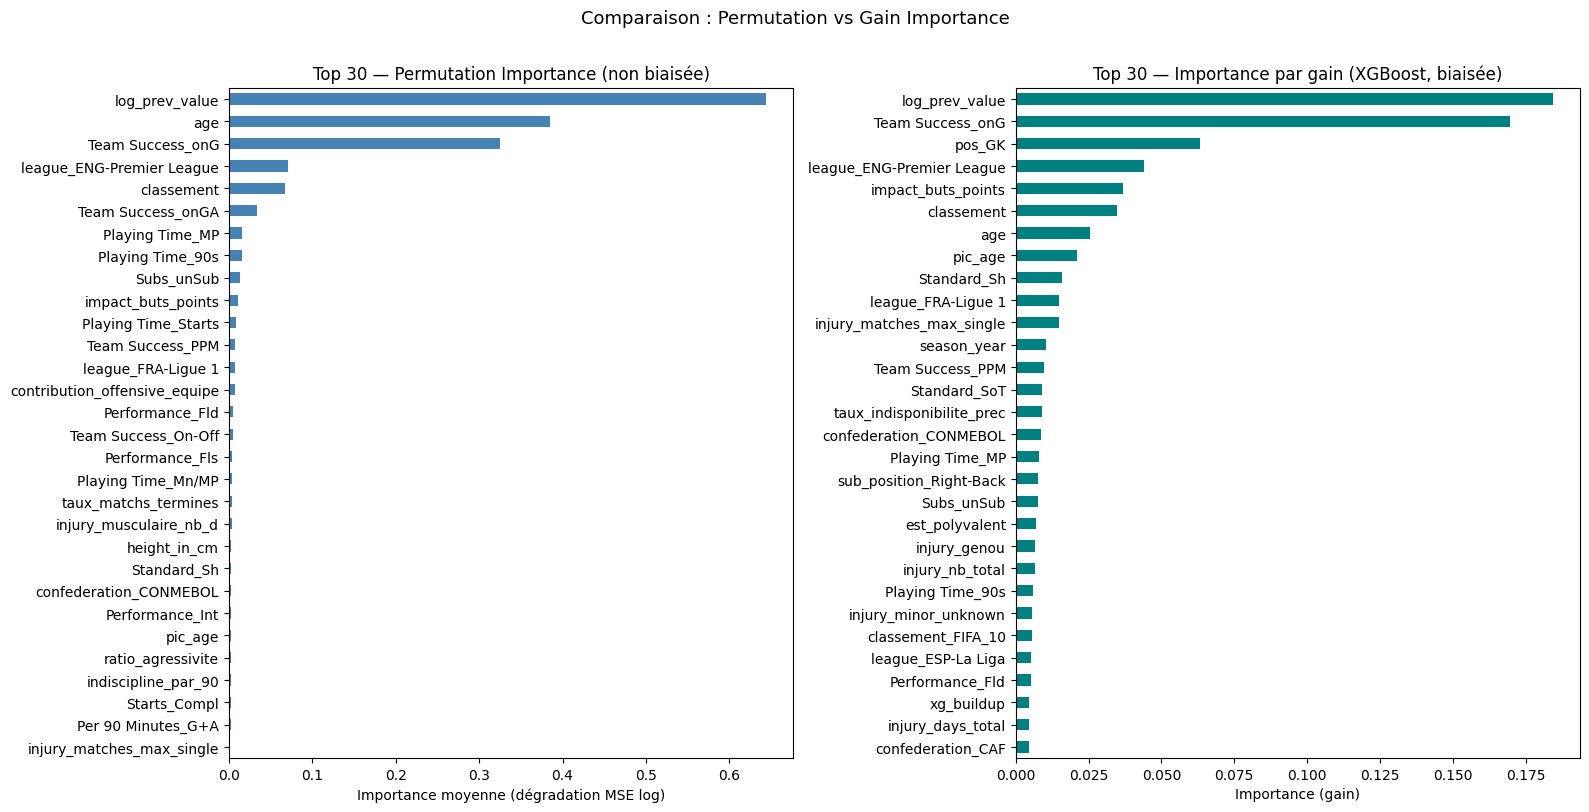

In [63]:
# Calculer la permutation importance sur le jeu de VALIDATION
# (sur le train on surestimerait l'importance car les arbres ont mémorisé le train)
print("Calcul permutation importance (peut prendre 2-3 minutes)...")

perm_result = permutation_importance(
    selector_model, X_val, y_val_log,
    n_repeats=10,           # 10 permutations par feature → estimation stable
    random_state=RANDOM_STATE,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

perm_imp = pd.Series(perm_result.importances_mean, index=X_train.columns)
perm_std = pd.Series(perm_result.importances_std,  index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

print(f"\nFeatures avec permutation importance > 0   : {(perm_imp > 0).sum()}")
print(f"Features avec permutation importance < 0   : {(perm_imp < 0).sum()} (mélanger améliore → bruit)")
print(f"\nTop 30 permutation importance :")
print(perm_imp.head(30).to_string())

# Comparaison gain vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

perm_imp.head(30).sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Top 30 — Permutation Importance (non biaisée)")
axes[0].set_xlabel("Importance moyenne (dégradation MSE log)")

importances.head(30).sort_values().plot(kind="barh", ax=axes[1], color="teal", edgecolor="none")
axes[1].set_title("Top 30 — Importance par gain (XGBoost, biaisée)")
axes[1].set_xlabel("Importance (gain)")

plt.suptitle("Comparaison : Permutation vs Gain Importance", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [64]:
# Sélection sur la base de la permutation importance
# On garde uniquement les features avec importance > 0 (mélanger les dégrade vraiment)
for seuil_perm, label_perm in [
    (0,    "Perm > 0  (toutes utiles)"),
    (0.001,"Perm > 0.001"),
    (0.005,"Perm > 0.005"),
]:
    features_perm = perm_imp[perm_imp > seuil_perm].index.tolist()
    if len(features_perm) < 5:
        print(f"Trop peu de features ({len(features_perm)}) pour seuil {seuil_perm}, skip")
        continue
    print(f"\n--- {label_perm} ({len(features_perm)} features) ---")

    pred_val_perm, pred_te_perm, _ = entrainer_stack(
        X_train[features_perm], y_train_log, X_val[features_perm], y_val_log,
        X_test[features_perm], y_val, w=sample_weights_train.values
    )
    res = evaluer_complet(label_perm, y_test, pred_te_perm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- Perm > 0  (toutes utiles) (89 features) ---
  MAPE : 41.34% | R² : 0.8829 | RMSE_log : 0.5196

--- Perm > 0.001 (35 features) ---
  MAPE : 40.49% | R² : 0.8747 | RMSE_log : 0.5210

--- Perm > 0.005 (16 features) ---
  MAPE : 41.11% | R² : 0.8656 | RMSE_log : 0.5305


#### B6.5 : Tableau comparatif final

=== COMPARAISON FINALE (Test) ===
                                      MAE            RMSE    MAPE      R² RMSE_log
Label                                                                             
Sans réduction                3,326,402 €     6,277,928 €  40.13%  0.8819   0.5292
ACP 95%                       4,312,060 €     8,280,227 €  53.06%  0.7946   0.5996
ACP 99%                       4,314,928 €     8,332,954 €  52.25%  0.7920   0.6085
ACP 99.9%                     4,391,372 €     8,397,385 €  52.38%  0.7887   0.6033
SFM top 50                    3,326,218 €     6,309,527 €  39.70%  0.8807   0.5280
SFM top 75                    3,307,547 €     6,200,633 €  39.63%  0.8848   0.5283
SFM top 100                   3,298,192 €     6,147,420 €  39.68%  0.8868   0.5257
Perm > 0  (toutes utiles)     3,357,485 €     6,252,419 €  41.34%  0.8829   0.5196
Perm > 0.001                  3,308,865 €     6,466,965 €  40.49%  0.8747   0.5210
Perm > 0.005                  3,372,857 €     6,697,8

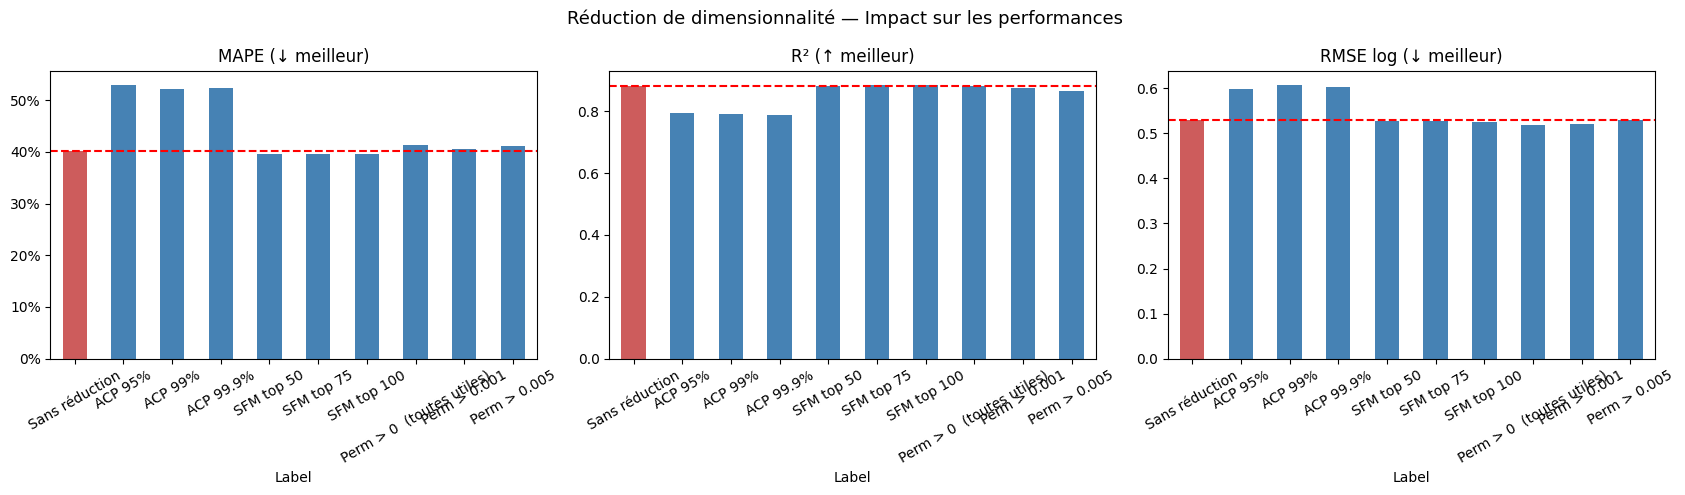

In [65]:
df_comp = pd.DataFrame(resultats_comparaison).set_index("Label")
df_comp["MAE"]  = df_comp["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["RMSE"] = df_comp["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["MAPE"] = df_comp["MAPE"].apply(lambda x: f"{x:.2%}")
df_comp["R²"]   = df_comp["R²"].apply(lambda x: f"{x:.4f}")
df_comp["RMSE_log"] = df_comp["RMSE_log"].apply(lambda x: f"{x:.4f}")

print("=== COMPARAISON FINALE (Test) ===")
print(df_comp.to_string())

# Visualisation
df_viz = pd.DataFrame(resultats_comparaison)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ["steelblue" if "Sans" not in l else "indianred" for l in df_viz["Label"]]

df_viz.set_index("Label")["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(res_base["MAPE"], color="red", lw=1.5, linestyle="--", label="baseline")

df_viz.set_index("Label")["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(res_base["R²"], color="red", lw=1.5, linestyle="--")

df_viz.set_index("Label")["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].axhline(res_base["RMSE_log"], color="red", lw=1.5, linestyle="--")

plt.suptitle("Réduction de dimensionnalité — Impact sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

### B7 : Modèles séparés : Gardiens / Joueurs de champ

**Ce qu'on teste :** spécialiser un modèle par position améliore-t-il les performances ?

**Ce qui varie ici :** la population d'entraînement (GK ou joueurs de champ).  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test.

**Hypothèse :** les gardiens ont des stats fondamentalement différentes (saves, CS%, SoTA...) des joueurs de champ (buts, xG, dribbles...). Un modèle unique fait des compromis.

#### B7.1 : Séparation des populations

In [66]:
mask_train_gk = X_train["pos_GK"] == 1
mask_val_gk   = X_val["pos_GK"] == 1
mask_test_gk  = X_test["pos_GK"] == 1

X_train_gk, y_train_gk = X_train[mask_train_gk], y_train[mask_train_gk]
X_val_gk,   y_val_gk   = X_val[mask_val_gk],     y_val[mask_val_gk]
X_test_gk,  y_test_gk  = X_test[mask_test_gk],   y_test[mask_test_gk]

X_train_champ, y_train_champ = X_train[~mask_train_gk], y_train[~mask_train_gk]
X_val_champ,   y_val_champ   = X_val[~mask_val_gk],     y_val[~mask_val_gk]
X_test_champ,  y_test_champ  = X_test[~mask_test_gk],   y_test[~mask_test_gk]

print(f"Gardiens         : {len(X_train_gk):>5} train | {len(X_val_gk):>4} val | {len(X_test_gk):>4} test")
print(f"Joueurs de champ : {len(X_train_champ):>5} train | {len(X_val_champ):>4} val | {len(X_test_champ):>4} test")

colonnes_position = ["pos_DF", "pos_FW", "pos_GK", "pos_MF"]

X_train_gk_feat    = X_train_gk.drop(columns=colonnes_position)
X_val_gk_feat      = X_val_gk.drop(columns=colonnes_position)
X_test_gk_feat     = X_test_gk.drop(columns=colonnes_position)

X_train_champ_feat = X_train_champ.drop(columns=colonnes_position)
X_val_champ_feat   = X_val_champ.drop(columns=colonnes_position)
X_test_champ_feat  = X_test_champ.drop(columns=colonnes_position)

Gardiens         :   567 train |  180 val |  133 test
Joueurs de champ :  6837 train | 2251 val | 1618 test


#### B7.2 : Tuning par groupe

On utilise `N_TRIALS_SPLIT = 50` (au lieu de 75) car les sous-populations sont plus petites et TPE converge plus vite sur des espaces de recherche réduits.

In [67]:
N_TRIALS_SPLIT = 20   # sous-populations plus petites → moins d'essais nécessaires

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor:   {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor:          {"tree_method": "hist", "enable_categorical": True,
                            "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0, "verbose": False},
    LGBMRegressor:         {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}

def espace_forest(trial):
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
    }

def espace_xgb(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def espace_lgbm(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials):
    fixed = FIXED_PARAMS[model_class]
    def objective(trial):
        params = {**espace_fn(trial), **fixed}
        model = model_class(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_ev)
        return np.sqrt(mean_squared_error(y_ev, preds))
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees":   (ExtraTreesRegressor,   espace_forest),
    "XGBoost":       (XGBRegressor,          espace_xgb),
    "LightGBM":      (LGBMRegressor,         espace_lgbm),
}

In [68]:
groupes = {
    "Gardiens":        (X_train_gk_feat,    y_train_gk,    X_val_gk_feat,    y_val_gk),
    "Joueurs de champ":(X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\n=== Tuning {nom_modele} — {nom_groupe} ===")
        study = tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials=N_TRIALS_SPLIT)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur RMSE : {study.best_value:,.0f} € | Params : {study.best_params}")


=== Tuning Random Forest — Gardiens ===


Best trial: 11. Best value: 4.13707e+06: 100%|██████████| 20/20 [00:23<00:00,  1.16s/it]


Meilleur RMSE : 4,137,074 € | Params : {'n_estimators': 500, 'max_depth': 17, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_features': 1.0}

=== Tuning Extra Trees — Gardiens ===


Best trial: 12. Best value: 4.04129e+06: 100%|██████████| 20/20 [00:15<00:00,  1.29it/s]


Meilleur RMSE : 4,041,291 € | Params : {'n_estimators': 500, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 1.0}

=== Tuning XGBoost — Gardiens ===


...

Meilleur RMSE : 6,529,760 € | Params : {'n_estimators': 1000, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 1.0}

=== Tuning XGBoost — Joueurs de champ ===


Best trial: 2. Best value: 5.87766e+06: 100%|██████████| 20/20 [03:41<00:00, 11.07s/it]


Meilleur RMSE : 5,877,657 € | Params : {'n_estimators': 1500, 'max_depth': 4, 'learning_rate': 0.05036929759271682, 'subsample': 0.8380309333333041, 'colsample_bytree': 0.668401034549142, 'min_child_weight': 9.253459525102285, 'reg_alpha': 0.0012035673919417052, 'reg_lambda': 0.000983283506345698}

=== Tuning LightGBM — Joueurs de champ ===


Best trial: 14. Best value: 5.98167e+06: 100%|██████████| 20/20 [01:35<00:00,  4.75s/it]

Meilleur RMSE : 5,981,670 € | Params : {'n_estimators': 2500, 'num_leaves': 162, 'max_depth': 3, 'learning_rate': 0.023628728014631548, 'subsample': 0.9146162078452422, 'colsample_bytree': 0.5639123296953079, 'reg_alpha': 0.9022997354131169, 'reg_lambda': 0.019129650226547227}


#### B7.3 : Entraînement des modèles spécifiques

Les modèles sont construits **une seule fois ici** et gelés pour la comparaison. On évite ainsi tout re-fit accidentel entre les étapes de comparaison validation et test.

In [69]:
# Construction des modèles finaux, spécifiques à chaque groupe
# On les construit ici une seule fois et on les garde gelés pour la comparaison

modeles_finaux_par_groupe = {}
for nom_groupe in groupes:
    modeles_finaux_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, _) in modeles_a_tuner.items():
        study = tuning_par_groupe[nom_groupe][nom_modele]
        modeles_finaux_par_groupe[nom_groupe][nom_modele] = model_class(
            **study.best_params, **FIXED_PARAMS[model_class]
        )

# Pré-entraînement des modèles spécifiques sur leur groupe respectif

modeles_groupe_entraines = {}
for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    modeles_groupe_entraines[nom_groupe] = {}
    for nom_modele, modele in modeles_finaux_par_groupe[nom_groupe].items():
        modele.fit(X_tr, y_tr)
        modeles_groupe_entraines[nom_groupe][nom_modele] = modele
        print(f"  {nom_groupe} / {nom_modele} : entraîné")

  Gardiens / Random Forest : entraîné
  Gardiens / Extra Trees : entraîné
  Gardiens / XGBoost : entraîné
  Gardiens / LightGBM : entraîné
  Joueurs de champ / Random Forest : entraîné
  Joueurs de champ / Extra Trees : entraîné
  Joueurs de champ / XGBoost : entraîné
  Joueurs de champ / LightGBM : entraîné


#### B7.4 : Comparaison modèle global vs modèle spécifique (validation)

On compare, sur chaque sous-groupe, le modèle global entraîné sur tout le train vs le modèle spécifique entraîné uniquement sur ce sous-groupe.

In [70]:
# Comparaison : modèle global vs modèle spécifique (validation)
sous_groupes_val = {
    "Gardiens":         (X_val_gk,    y_val_gk,    X_val_gk_feat),
    "Joueurs de champ": (X_val_champ, y_val_champ, X_val_champ_feat),
}

comparaison_groupes = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_val.items():
    for nom_modele in modeles_a_tuner:
        # Modèle global
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        # Modèle spécifique
        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes.append({
            "Groupe":          nom_groupe,
            "Modèle":          nom_modele,
            "MAE global":      mae_global,
            "R² global":       r2_global,
            "MAE spécifique":  mae_groupe,
            "R² spécifique":   r2_groupe,
            "Gain MAE":        mae_global - mae_groupe,
        })

df_comparaison_groupes = pd.DataFrame(comparaison_groupes)
print("CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes.to_string(index=False))

CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 2.388924e+06   0.852662    2.597447e+06       0.818090 -208523.150314
        Gardiens   Extra Trees 2.008435e+06   0.887970    2.521511e+06       0.826416 -513076.073535
        Gardiens       XGBoost 2.132582e+06   0.867147    2.353861e+06       0.842355 -221278.677718
        Gardiens      LightGBM 2.159977e+06   0.862008    2.552644e+06       0.818436 -392666.692998
Joueurs de champ Random Forest 3.538075e+06   0.866254    3.571384e+06       0.863393  -33309.608402
Joueurs de champ   Extra Trees 3.339574e+06   0.880130    3.411047e+06       0.874810  -71473.214134
Joueurs de champ       XGBoost 3.229654e+06   0.903474    3.413077e+06       0.898566 -183423.562104
Joueurs de champ      LightGBM 3.279775e+06   0.898126    3.443645e+06       0.894944 -163870.018851


#### B7.5 : Évaluation finale sur le test

In [71]:
sous_groupes_test = {
    "Gardiens":         (X_test_gk,    y_test_gk,    X_test_gk_feat),
    "Joueurs de champ": (X_test_champ, y_test_champ, X_test_champ_feat),
}

comparaison_groupes_test = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_test.items():
    for nom_modele in modeles_a_tuner:
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes_test.append({
            "Groupe":         nom_groupe,
            "Modèle":         nom_modele,
            "MAE global":     mae_global,
            "R² global":      r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique":  r2_groupe,
            "Gain MAE":       mae_global - mae_groupe,
        })

df_comparaison_groupes_test = pd.DataFrame(comparaison_groupes_test)
print("CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes_test.to_string(index=False))

CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 2.313508e+06   0.845582    2.862426e+06       0.791556 -548917.376005
        Gardiens   Extra Trees 2.114835e+06   0.869319    2.627779e+06       0.830846 -512943.987426
        Gardiens       XGBoost 2.316005e+06   0.859409    2.648847e+06       0.817082 -332842.590622
        Gardiens      LightGBM 2.255087e+06   0.867032    2.924670e+06       0.777843 -669583.457796
Joueurs de champ Random Forest 3.758147e+06   0.866396    3.790406e+06       0.863844  -32259.337656
Joueurs de champ   Extra Trees 3.467939e+06   0.882207    3.531724e+06       0.879014  -63784.980404
Joueurs de champ       XGBoost 3.428888e+06   0.891730    3.641382e+06       0.886945 -212493.427758
Joueurs de champ      LightGBM 3.537675e+06   0.881340    3.702512e+06       0.879737 -164836.647244


## Partie C : Comparaison finale et sélection du meilleur modèle

Toutes les approches de la partie B comparées dans un **tableau unique**, sur le **même test**, avec le **même pipeline de base**. La comparaison est donc équitable.

**Métriques :**

| Métrique | Rôle | Sens |
|---|---|---|
| **MAPE** | Principale | Erreur relative en % — indépendante de l'échelle de valeur |
| **RMSE log** | Secondaire | Équivalent MAPE, stable numériquement |
| **R²** | Tertiaire | Variance expliquée — sensible aux erreurs sur les grandes valeurs |
| **MAE** | Contexte | Erreur absolue en € — dépendante de l'échelle |

### C.1 : Tableau comparatif

In [72]:
# === Helpers de prédiction robustes aux dérives de colonnes ===

def get_feature_names(modele):
    """Récupère la liste des features attendues par un modèle, quel que soit son type."""
    if hasattr(modele, "get_booster"):          # XGBoost
        try:
            fn = modele.get_booster().feature_names
            if fn: return fn
        except Exception:
            pass
    if hasattr(modele, "booster_"):              # LightGBM
        try:
            return list(modele.booster_.feature_name())
        except Exception:
            pass
    if hasattr(modele, "feature_names_"):         # CatBoost
        return list(modele.feature_names_)
    if hasattr(modele, "feature_names_in_"):       # sklearn / Pipeline (RF, ET, SVR, ElasticNet)
        return list(modele.feature_names_in_)
    return None  # type inconnu -> pas d'alignement possible, on laisse X tel quel

def aligner_X(X, feature_names, nom_modele=""):
    """Réaligne les colonnes de X sur celles attendues par le modèle :
    colonnes manquantes -> ajoutées à 0, colonnes en trop -> supprimées."""
    if feature_names is None:
        return X
    manquantes = [c for c in feature_names if c not in X.columns]
    en_trop    = [c for c in X.columns if c not in feature_names]
    if manquantes:
        print(f"    ⚠️ {nom_modele} : {len(manquantes)} colonne(s) manquante(s) "
              f"réinjectée(s) à 0 -> {manquantes[:5]}{'...' if len(manquantes) > 5 else ''}")
        X = X.copy()
        for c in manquantes:
            X[c] = 0
    if en_trop:
        X = X.drop(columns=en_trop)
    return X[feature_names]

def predire_aligne(modele, X, nom_modele=""):
    fn = get_feature_names(modele)
    return modele.predict(aligner_X(X, fn, nom_modele))

In [73]:
# === C.1 : Tableau comparatif — TOUS les modèles évalués sur le MÊME test figé ===
# On n'utilise plus jamais X_test / y_test "vivants" : uniquement les versions
# figées juste après la Partie A. Ça garantit une comparaison réellement équitable,
# y compris pour les approches B5/B6 qui ont été entraînées sur un train filtré
# mais qui restent évaluables sur le test complet (le modèle n'a pas besoin
# que le test soit filtré pour produire une prédiction).

taille_ref = len(y_test_final)
print(f"Référence : {taille_ref} lignes (test set Partie A, figé)")

def verif(name, arr):
    arr = np.array(arr, dtype=float)
    if len(arr) != taille_ref:
        print(f"    {name} ignoré : taille {len(arr)} ≠ {taille_ref}")
        return None
    return np.clip(arr, 0, None)

def calcul_metriques(name, y_pred):
    y_pred = verif(name, y_pred)
    if y_pred is None:
        return
    mae      = mean_absolute_error(y_test_final, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test_final, y_pred))
    mape     = mean_absolute_percentage_error(y_test_final, y_pred)
    r2       = r2_score(y_test_final, y_pred)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_test_final), np.log1p(y_pred)))
    n, p     = X_test_final.shape
    r2_adj   = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    results.append({"Modèle": name, "MAPE": mape, "RMSE_log": rmse_log,
                     "R²": r2, "R²_adj": r2_adj, "MAE": mae, "RMSE": rmse, "preds": y_pred})

results = []

# --- B3 : Stacking OOF — RECALCULÉ sur X_test_final (ne pas faire confiance
# à pred_test_stack/pred_test_moyenne déjà en mémoire, qui peuvent être obsolètes
# si des cellules ont été rejouées dans le désordre) ---
preds_test_base_final = {
    nom: np.expm1(predire_aligne(modeles_tuned_log[nom], X_test_final, nom))
    for nom in base_models_log
}
X_meta_test_b3 = pd.DataFrame(preds_test_base_final)

pred_test_stack_final    = meta_modele.predict(X_meta_test_b3)
pred_test_moyenne_final  = X_meta_test_b3.mean(axis=1)

calcul_metriques("Blend Moyenne (B3 — Stacking initial)", pred_test_moyenne_final)
calcul_metriques("Stacking OOF (B3 — Stacking initial)",  pred_test_stack_final)

# --- B4 : celui-ci a matché (1751 lignes), on le garde tel quel ---
calcul_metriques(f"Stacking Tuné ({meilleure_transfo}) (B4 — Transfo)", pred_test_tuned_eur)

# --- B1 (cible brute) / B2 (cible log) : on repredit sur X_test_final ---
modeles_bruts = {
    "Random Forest (B1)": (modeles_tuned["Random Forest"],       X_test_final,          False),
    "Extra Trees (B1)":   (modeles_tuned["Extra Trees"],         X_test_final,          False),
    "XGBoost (B1)":       (modeles_tuned["XGBoost"],             X_test_final,          False),
    "LightGBM (B1)":      (modeles_tuned["LightGBM"],            X_test_final,          False),
    "CatBoost (B1)":      (modeles_tuned["CatBoost"],            X_test_final,          False),
    "SVR (B1)":           (modeles_tuned_sans_nan["SVR"],        X_test_sans_nan_final, False),
    "ElasticNet (B1)":    (modeles_tuned_sans_nan["ElasticNet"], X_test_sans_nan_final, False),
}
modeles_log = {
    "Random Forest log (B2)": (modeles_tuned_log["Random Forest (log)"],       X_test_final,          True),
    "Extra Trees log (B2)":   (modeles_tuned_log["Extra Trees (log)"],         X_test_final,          True),
    "XGBoost log (B2)":       (modeles_tuned_log["XGBoost (log)"],             X_test_final,          True),
    "LightGBM log (B2)":      (modeles_tuned_log["LightGBM (log)"],            X_test_final,          True),
    "CatBoost log (B2)":      (modeles_tuned_log["CatBoost (log)"],            X_test_final,          True),
    "SVR log (B2)":           (modeles_tuned_log_sans_nan["SVR (log)"],        X_test_sans_nan_final, True),
    "ElasticNet log (B2)":    (modeles_tuned_log_sans_nan["ElasticNet (log)"], X_test_sans_nan_final, True),
}
for name, (modele, X_ev, is_log) in {**modeles_bruts, **modeles_log}.items():
    y_pred_raw = np.expm1(predire_aligne(modele, X_ev, name)) if is_log else predire_aligne(modele, X_ev, name)
    calcul_metriques(name, y_pred_raw)

# --- B5 (sans outliers) ---
preds_b5_log_final = {nom: predire_aligne(modeles_finaux[nom], X_test_final, nom) for nom in base_models}
X_meta_test_final   = pd.DataFrame(preds_b5_log_final)
pred_test_b5_final  = np.expm1(meta.predict(X_meta_test_final))
calcul_metriques("Stacking OOF, train sans outliers (B5)", pred_test_b5_final)

# --- B6 (réduction de dimensionnalité) ---
# ⚠️ Ces prédictions (pred_te_acp / pred_te_sfm / pred_te_perm) ont été calculées
# à l'intérieur d'une boucle, sur le test filtré B5, avec des transformeurs
# (PCA / sélection de features) qui n'ont pas été conservés en variables réutilisables.
# On ne peut donc PAS les recalculer proprement sur X_test_final sans revenir modifier B6
# (sauvegarder pca/scaler_acp et features_sel dans des dicts au moment de leur fit).
# Faute de ça, on les exclut du tableau final plutôt que d'afficher un chiffre trompeur.
print("B6 (ACP / SFM / Permutation) exclu du tableau : transformeurs non sauvegardés, "
      "voir note ci-dessus pour les inclure proprement.")

# Tableau comparatif final
df_all         = pd.DataFrame(results).set_index("Modèle").sort_values("MAE")
df_recap_final = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

df_disp = df_all.drop(columns=["preds"]).copy()
df_disp["MAPE"]     = df_disp["MAPE"].apply(lambda x: f"{x:.2%}")
df_disp["RMSE_log"] = df_disp["RMSE_log"].apply(lambda x: f"{x:.4f}")
df_disp["R²"]       = df_disp["R²"].apply(lambda x: f"{x:.4f}")
df_disp["R²_adj"]   = df_disp["R²_adj"].apply(lambda x: f"{x:.4f}")
df_disp["MAE"]      = df_disp["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_disp["RMSE"]     = df_disp["RMSE"].apply(lambda x: f"{x:>12,.0f} €")

print("CLASSEMENT FINAL — Toutes approches (Test figé Partie A, trié par MAE croissant)")
print(df_disp.to_string())

Référence : 1751 lignes (test set Partie A, figé)
    ⚠️ LightGBM (log) : 27 colonne(s) manquante(s) réinjectée(s) à 0 -> ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    ⚠️ LightGBM (B1) : 27 colonne(s) manquante(s) réinjectée(s) à 0 -> ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    ⚠️ LightGBM log (B2) : 27 colonne(s) manquante(s) réinjectée(s) à 0 -> ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    ⚠️ XGBoost : 8 colonne(s) manquante(s) réinjectée(s) à 0 -> ['Performance_Gls_nor', 'Performance_Ast_nor', 'Performance_Saves_nor', 'Standard_SoT%_nor', 'Standard_G/Sh_nor']...
    ⚠️ LightGBM : 35 colonne(s) manquante(s) réinjectée(s) à 0 -> ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    ⚠️ CatBoost : 8 colonne(s) manquante(s) r

### C.2 : Visualisation comparative

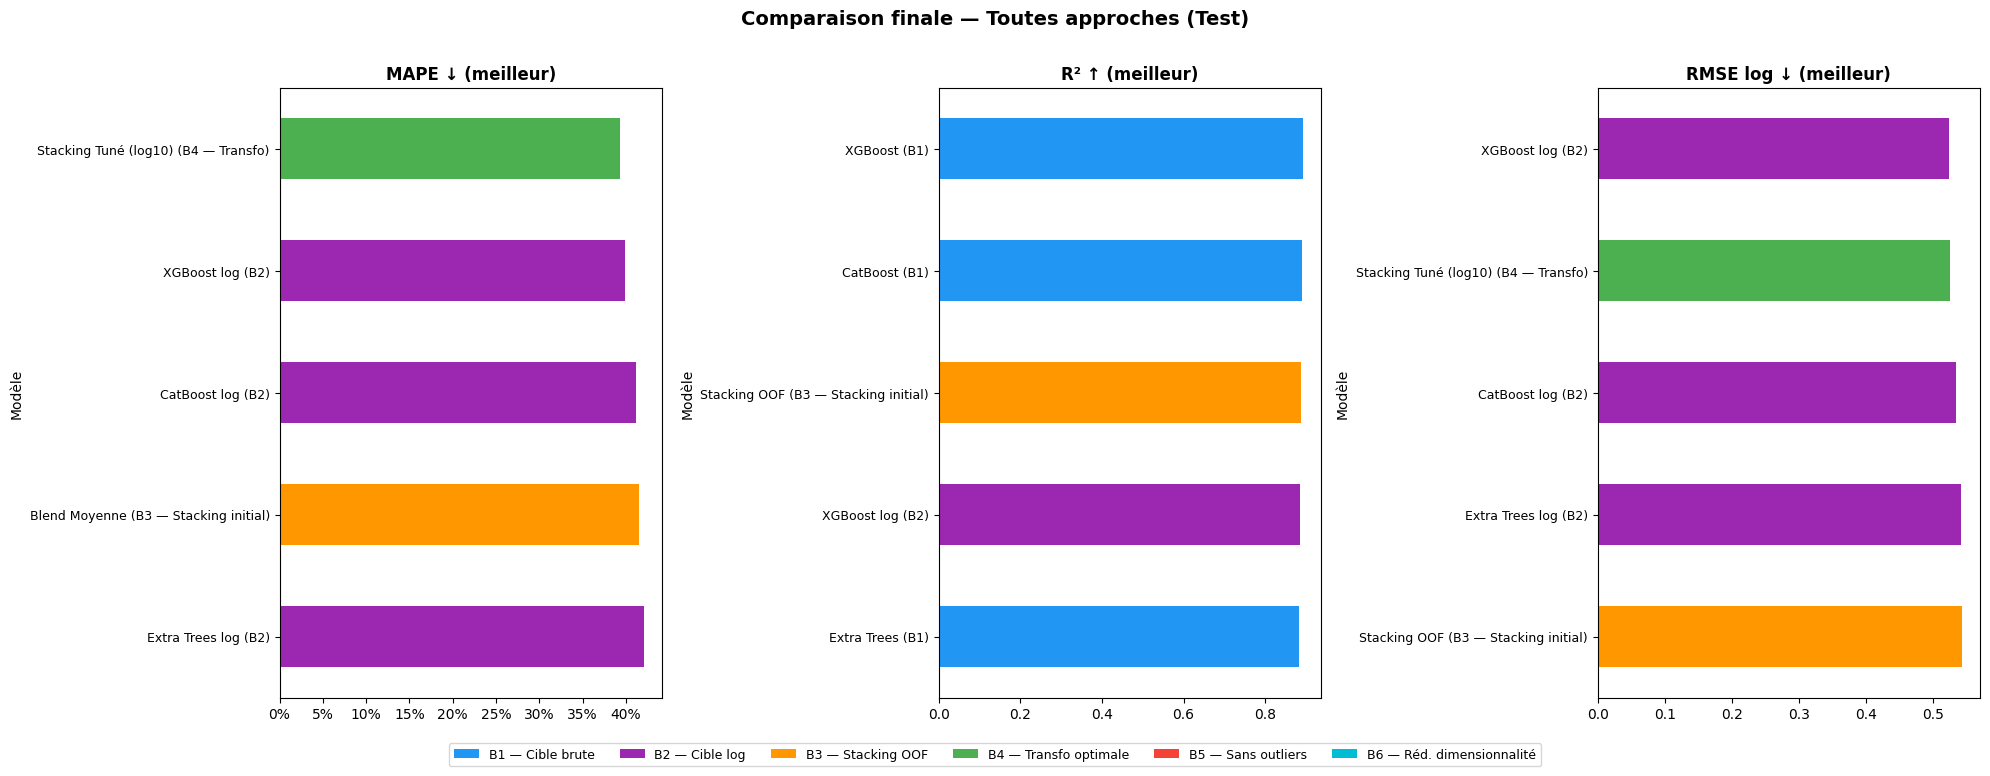

In [74]:
def get_color(lbl):
    if "B1" in lbl: return "#2196F3"
    if "B2" in lbl: return "#9C27B0"
    if "B3" in lbl: return "#FF9800"
    if "B4" in lbl: return "#4CAF50"
    if "B5" in lbl: return "#F44336"
    if "B6" in lbl: return "#00BCD4"
    return "#9E9E9E"

colors = [get_color(l) for l in df_all.index]

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(df_all) * 0.4)))
for ax, col, title, ascending in [
    (axes[0], "MAPE",     "MAPE ↓ (meilleur)",      True),
    (axes[1], "R²",       "R² ↑ (meilleur)",         False),
    (axes[2], "RMSE_log", "RMSE log ↓ (meilleur)",   True),
]:
    # Sélection uniquement des 5 premiers modèles pour la métrique courante
    df_top5 = df_all[col].sort_values(ascending=ascending).head(5)
    colors_top5 = [get_color(l) for l in df_top5.index]

    df_top5.plot(kind="barh", ax=ax, color=colors_top5, edgecolor="none")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.invert_yaxis()  # Le #1 se retrouve en haut du graphique
    ax.tick_params(axis="y", labelsize=9)

    if col == "MAPE":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
legend = [
    Patch(facecolor="#2196F3", label="B1 — Cible brute"),
    Patch(facecolor="#9C27B0", label="B2 — Cible log"),
    Patch(facecolor="#FF9800", label="B3 — Stacking OOF"),
    Patch(facecolor="#4CAF50", label="B4 — Transfo optimale"),
    Patch(facecolor="#F44336", label="B5 — Sans outliers"),
    Patch(facecolor="#00BCD4", label="B6 — Réd. dimensionnalité"),
]
fig.legend(handles=legend, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Comparaison finale — Toutes approches (Test)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### C.3 : Modèle retenu et analyse par tranche

In [75]:
champion_row   = df_recap_final.iloc[0]
champion_lbl   = champion_row["Modèle"]
preds_champion = champion_row["preds"]

print(f"MODÈLE RETENU : {champion_lbl}")
print(f"  MAPE     : {champion_row['MAPE']:.2%}")
print(f"  R²       : {champion_row['R²']:.4f}")
print(f"  MAE      : {champion_row['MAE']:>12,.0f} €")
print(f"  RMSE_log : {champion_row['RMSE_log']:.4f}")

MODÈLE RETENU : Stacking OOF (B3 — Stacking initial)
  MAPE     : 51.95%
  R²       : 0.8877
  MAE      :    3,219,008 €
  RMSE_log : 0.5432
